In [3]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [1]:
# scipy.ndimage.median_filter
import time
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

## **gpu 사용량 확인 함수**

In [ ]:
# class NetGPU:

#     def __init__(self):
#         if torch.cuda.is_available():
#             self.base = torch.cuda.memory_allocated()
#             torch.cuda.reset_peak_memory_stats()

#     def __call__(self):
#         if not torch.cuda.is_available():
#             return ""

#         peak = torch.cuda.max_memory_allocated()
#         net_used = (peak - self.base) / (1024**2)

#         # 다음 스텝 측정을 위해 현재 상태를 새 '0점'으로 리셋
#         self.base = torch.cuda.memory_allocated()
#         torch.cuda.reset_peak_memory_stats()

#         if net_used < 0.05:  # 0.05MB 미만 변동은 그냥 안 쓴 걸로 처리
#             return " | GPU:    0.0MB"
#         return f" | GPU:  +{net_used:4.1f}MB"


# gpu = NetGPU()  # 이제부터 {gpu()} 부르면 얘가 일함





# t = time.perf_counter()

# results, mask_binary, vis_yolo = detect_objects_yolo(...)

# print(f"[TIME] \
# YOLO:   \
# {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")

# **[시작] 카메라 호출**

### 조립체 인지 PCA

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.1m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (10 프레임 대기)


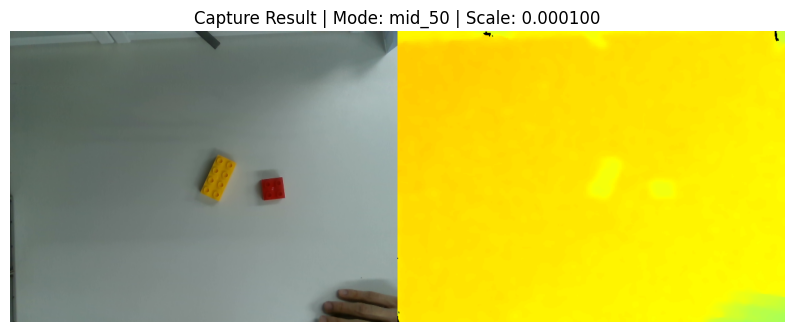

✅ 카메라 스트리밍 안전 종료 완료.

[INFO] contour object count: 5


In [6]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0] # 첫 번째 카메라 선택

# 필요한 데이터 한 번에 추출! (시각화 켜기)
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

# color_rgb, depth, intrinsics, scale

depth_img = depth.copy()

color_img_rgb = color_rgb.copy()

depth_scale = scale

# ------------------------------------------------------------
# 1. RANSAC 바닥 제거 + object mask 생성
# ------------------------------------------------------------
result = ivl.extract_object_components_with_pca(
    depth_img=depth_img,
    depth_scale=depth_scale,
    intrinsics=intrinsics,
    color_img_rgb=color_img_rgb,

    # YOLO mask 없으면 None
    # YOLO mask 있으면 and_mask=yolo_mask_binary
    and_mask=None,

    median_ksize=3,                  # 약한 median
    ransac_distance_threshold=0.006,  # 바닥 plane inlier 기준, 6mm
    object_min_plane_dist=0.010,      # 바닥에서 10mm 이상 튀어나온 것만 객체
    min_area_px=80,
    morph_open_ksize=3,
    morph_close_ksize=5,
    show=False,
    visualize=False
)

# print("\n[RANSAC Plane]")
# print("plane ax + by + cz + d = 0")
# print(result["plane"])

# ------------------------------------------------------------
# 2. RANSAC 결과에서 object mask 가져오기
# ------------------------------------------------------------
object_mask = result["object_mask"]
xyz_map = result["xyz_map"]
valid_mask = result["valid_mask"]
floor_mask = result["floor_mask"]
plane_dist_map = result["plane_dist_map"]

# ------------------------------------------------------------
# 3. Contour 기준 PCA 추출
# ------------------------------------------------------------
contour_objects = ivl.extract_contour_pca_from_mask(
    object_mask=object_mask,
    xyz_map=xyz_map,
    valid_mask=valid_mask,
    min_contour_area=80
)

print("\n[INFO] contour object count:", len(contour_objects))

# ------------------------------------------------------------
# 4. Contour + PCA 축 시각화
# ------------------------------------------------------------

visualize = False
if visualize:
    vis_contour_pca = ivl.visualize_contour_pca_axes(
        color_img_rgb=color_img_rgb,
        object_mask=object_mask,
        contour_objects=contour_objects,
        draw_mask=True,
        draw_contour=True,
        draw_min_rect=True,
        axis_len_mode="pca_length",   # 실제 contour 투영 길이 기반
        fixed_axis_len=80
    )

if visualize:
    plt.figure(figsize=(7, 5))
    plt.imshow(object_mask, cmap="gray")
    plt.title("RANSAC Object Mask")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.imshow(floor_mask, cmap="gray")
    plt.title("RANSAC Floor Mask")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.imshow(plane_dist_map * 1000, cmap="jet")
    plt.colorbar(label="Distance from RANSAC plane [mm]")
    plt.title("Plane Distance Map [mm]")
    plt.axis("off")
    plt.show()

# ------------------------------------------------------------
# 6. 결과 출력
# ------------------------------------------------------------

debug=False
if debug:
    print("\n[Contour PCA Result]")
    for i, obj in enumerate(contour_objects):
        print(f"\n--- Object {i} ---")


        # print("[Contour]")
        # print("area_px:", obj["area_px"])
        # print("bbox_xywh:", obj["bbox_xywh"])
        print("center_uv:", obj["center_uv"])

        print("\n[2D PCA from Contour Mask]")
        print("major_axis_uv:", obj["major_axis_uv"])
        print("minor_axis_uv:", obj["minor_axis_uv"])
        print("angle_deg:", obj["angle_deg"])
        # print("major_length_px:", obj["major_length_px"])
        # print("minor_length_px:", obj["minor_length_px"])
        # print("eigvals_2d:", obj["eigvals_2d"])

        if "center_xyz" in obj:
            print("\n[3D PCA from Contour Mask]")
            # print("center_xyz [m]:", obj["center_xyz"])
            print("center_xyz [mm]:", obj["center_xyz"] * 1000)

            # print("major_axis_xyz:", obj["major_axis_xyz"])
            # print("middle_axis_xyz:", obj["middle_axis_xyz"])
            # print("minor_axis_xyz:", obj["minor_axis_xyz"])

            print("major_length_mm:", obj["major_length_m"] * 1000)
            print("middle_length_mm:", obj["middle_length_m"] * 1000)
            print("minor_length_mm:", obj["minor_length_m"] * 1000)

            print("eigvals_3d:", obj["eigvals_3d"])


        print("--------------------")

## **제작중인 함수**

In [ ]:
import INUVisionLib as ivl
import copy
import math

import torch

def fine_correct(final_obj_fine,
    color_rgb,
    depth,
    scale,
    intrinsics,
    plane_model,
    V_visualize=True
    ):

    t = time.perf_counter()

    img_rgb = color_rgb.copy()
    if img_rgb.dtype != np.uint8:
        img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

    # ============================================================
    # [NEW] Step 0: RANSAC 뎁스 기반 바닥 제거
    # 바닥면을 찾아 해당 영역을 검은색(0,0,0)으로 칠합니다.
    # ============================================================
    # 0-1. 뎁스를 3D 공간 좌표로 변환
    xyz_map, valid_mask = ivl.depth_to_xyz_map(depth, scale, intrinsics)
    valid_points = xyz_map[valid_mask]

    print(f"[TIME] \
    f - 1. xyz trans   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # 0-2. RANSAC 평면 피팅 (바닥 찾기)
    # best_plane, _ = ivl.fit_plane_ransac_numpy(valid_points, distance_threshold=0.006)
    best_plane = plane_model

    print(f"[TIME] \
    f - 2 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # 0-3. 바닥 평면으로부터의 Z축 거리(높이) 계산
    dist_map = ivl.compute_plane_distance_map(xyz_map, valid_mask, best_plane)

    print(f"[TIME] \
    f - 3 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # 0-4. 바닥에서 1cm(0.01m) 이상 튀어나온 영역만 마스킹 (1cm 미만은 바닥으로 간주)
    ransac_mask = (dist_map > 0.010).astype(np.uint8) * 255

    # 노이즈를 살짝 지워주기 위해 모폴로지 열기(Open) 적용
    kernel_open = np.ones((9, 9), np.uint8)
    ransac_mask = cv2.morphologyEx(ransac_mask, cv2.MORPH_OPEN, kernel_open)

    # 닫기(Close)를 통해 가까운 덩어리들을 1차로 뭉치기
    kernel_close = np.ones((9, 9), np.uint8)
    ransac_mask = cv2.morphologyEx(ransac_mask, cv2.MORPH_CLOSE, kernel_close)

    print(f"[TIME] \
    f - 4 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # --------------------------------------------------------
    # 1. Dilation (팽창) 적용: 테두리 복구 및 덩어리들 확실히 연결
    # --------------------------------------------------------
    kernel_dilate = np.ones((5, 5), np.uint8)
    ransac_mask = cv2.dilate(ransac_mask, kernel_dilate, iterations=1)

    print(f"[TIME] \
    f - 5 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # --------------------------------------------------------
    # 2. [NEW] Convex Hull (볼록 선체) 적용
    # 오목하게 파인 부분을 고무줄로 묶듯 팽팽하게 채워서 완벽한 한 덩어리로 만듭니다.
    # --------------------------------------------------------
    # 먼저 현재 마스크에서 윤곽선들을 찾습니다.
    contours_ransac, _ = cv2.findContours(ransac_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convex Hull을 그려넣을 빈 캔버스 생성
    hull_mask = np.zeros_like(ransac_mask)

    for cnt in contours_ransac:
        # 너무 작은 자잘한 노이즈는 무시 (필요시 수치 조절)
        if cv2.contourArea(cnt) < 200:
            continue
            
        # 윤곽선을 감싸는 최소한의 볼록 다각형(Convex Hull) 좌표 계산
        hull = cv2.convexHull(cnt)
        
        # 빈 캔버스에 볼록 다각형을 내부까지 꽉 채워서(thickness=-1) 흰색(255)으로 그림
        cv2.drawContours(hull_mask, [hull], -1, 255, thickness=-1)

    print(f"[TIME] \
    f - 6 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # --------------------------------------------------------
    # 3. [NEW] 최종 Padding (추가 팽창) 적용
    # Convex Hull로 묶인 객체의 바깥쪽에 여유 공간(패딩)을 줍니다.
    # --------------------------------------------------------
    kernel_pad = np.ones((7, 7), np.uint8) # 패딩 두께를 늘리려면 (7, 7) 등으로 조절
    ransac_mask = cv2.dilate(hull_mask, kernel_pad, iterations=1) # 다음 단계로 넘기기 위해 변수명 원상복구 
    # 0-5. RGB 이미지에 마스크 씌우기 (바닥 부분은 완전히 검정색으로)
    img_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=ransac_mask)

    print(f"[TIME] \
    f - 7 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # ============================================================
    # Step 1: 양방향 필터 (Bilateral Filter) 적용
    # ============================================================
    filtered_rgb = cv2.bilateralFilter(img_rgb, d=5, sigmaColor=50, sigmaSpace=50)

    # ============================================================

    print(f"[TIME] \
    f - 8 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # Step 2: LAB 색공간 변환 및 채널 분리
    # (참고: 앞서 배경을 칠한 검정색은 LAB에서 L=0, a=128, b=128이 됩니다!)
    # ============================================================

    lab = cv2.cvtColor(filtered_rgb, cv2.COLOR_RGB2LAB)
    L, a, b = cv2.split(lab)

    print(f"[TIME] \
    f - 9 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # ============================================================
    # Step 3: 핵심 전처리 - 128(무채색 배경)과의 절대 거리 계산
    # ============================================================
    a_dist = cv2.absdiff(a, 128)
    b_dist = cv2.absdiff(b, 128)

    # ============================================================
    # Step 4: Min-Max 정규화 (상대평가 스케일링)
    # ============================================================

    a_norm = cv2.normalize(a_dist, None, 0, 255, cv2.NORM_MINMAX)
    b_norm = cv2.normalize(b_dist, None, 0, 255, cv2.NORM_MINMAX)

    # ============================================================
    # Step 5: a와 b 채널 병합
    # ============================================================
    ab_combined = cv2.max(a_norm, b_norm)

    print(f"[TIME] \
    f - 10 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # ============================================================
    # 시각화 1 (각 단계별 변화 및 RANSAC 마스크 확인)
    # ============================================================

    images = [
        ("0. RANSAC Floor Mask", ransac_mask, 'gray'),
        ("1. Masked RGB (Floor Removed)", img_rgb, None),
        ("2. Bilateral Filtered", filtered_rgb, None),
        ("3. Raw 'a' Channel", a, 'gray'),
        ("4. Raw 'b' Channel", b, 'gray'),
        ("5. |a - 128| Normalized", a_norm, 'gray'),
        ("6. |b - 128| Normalized", b_norm, 'gray'),
        ("7. Final Signal for K-Means", ab_combined, 'gray')
    ]
    if V_visualize:
        plt.figure(figsize=(20, 10))
        for i, (title, img, cmap) in enumerate(images):
            # 2행 4열 구조로 배치
            plt.subplot(2, 4, i + 1)
            plt.title(title)
            if cmap == 'gray':
                plt.imshow(img, cmap='gray', vmin=0, vmax=255)
            else:
                plt.imshow(img)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    # ============================================================
    # Step 8: 이진화 및 모폴로지 정리
    # ============================================================

    _, binary_mask = cv2.threshold(ab_combined, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((7, 7), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    # ====================================================================

    print(f"[TIME] \
    f - 11 \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # ============================================================
    # Step 9: 쿠키 틀 바인딩 및 규격화된 pose_table 생성
    # ============================================================
    result_img = color_rgb.copy()
    fine_pose_table = []  # <--- [NEW] 리턴할 테이블 배열

    for global_idx, obj in enumerate(final_obj_fine):
        raw_name = obj.get("class_name", "unknown")
        yolo_mask_bool = np.asarray(obj["mask"], dtype=bool)

        local_cookie_mask = np.zeros_like(binary_mask)
        local_cookie_mask[yolo_mask_bool] = binary_mask[yolo_mask_bool]

        contours_local, _ = cv2.findContours(local_cookie_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours_local: continue

        best_cnt = max(contours_local, key=cv2.contourArea)
        if cv2.contourArea(best_cnt) < 200: continue

        rect = cv2.minAreaRect(best_cnt)
        M = cv2.moments(best_cnt)
        if M["m00"] == 0: continue
        cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])

        width, height = rect[1][0], rect[1][1]
        aspect_ratio = max(width, height) / min(width, height) if min(width, height) > 0 else 1.0

        if aspect_ratio >= 1.5:
            # ============================================================
            # [수정] PCA 대신 minAreaRect 박스의 단축 방향으로 yaw 계산
            # 기준:
            # - 영상 좌표계에서 위쪽 방향 = -Y
            # - 단축 벡터가 위쪽(-Y)을 향하도록 방향 선택
            # - atan2(x, -y)로 수직 위쪽 기준 yaw 계산
            # ============================================================

            box_pts = cv2.boxPoints(rect).astype(np.float64)  # shape: (4, 2)

            # ------------------------------------------------------------
            # 1. minAreaRect 박스의 인접 edge 2개만 보면 됨
            #    box_pts는 사각형 꼭짓점이 순서대로 들어있으므로
            #    edge0, edge1은 서로 수직인 두 변 방향
            # ------------------------------------------------------------
            edge0 = box_pts[1] - box_pts[0]
            edge1 = box_pts[2] - box_pts[1]

            len0 = np.linalg.norm(edge0)
            len1 = np.linalg.norm(edge1)

            # ------------------------------------------------------------
            # 2. 더 짧은 edge를 단축 방향 벡터로 선택
            # ------------------------------------------------------------
            if len0 <= len1:
                minor_v = edge0
            else:
                minor_v = edge1

            # ------------------------------------------------------------
            # 3. 방향 통일
            #    영상 좌표계는 y가 아래로 증가하므로,
            #    위쪽을 향하는 벡터는 y 성분이 음수여야 함.
            # ------------------------------------------------------------
            if minor_v[1] > 0:
                minor_v = -minor_v

            # y가 거의 0인 수평 단축일 경우 방향이 애매하므로
            # x 양수 방향을 +90도로 통일하고 싶으면 이 처리 추가
            if abs(minor_v[1]) < 1e-6 and minor_v[0] < 0:
                minor_v = -minor_v

            # ------------------------------------------------------------
            # 4. 정규화
            # ------------------------------------------------------------
            norm = np.linalg.norm(minor_v)
            if norm < 1e-6:
                continue

            chosen_v = minor_v / norm

            # ------------------------------------------------------------
            # 5. 영상 좌표계 -Y 방향 기준 yaw 계산
            #    chosen_v = [0, -1] 이면 yaw = 0도
            #    chosen_v = [1,  0] 이면 yaw = +90도
            #    chosen_v = [-1, 0] 이면 yaw = -90도
            # ------------------------------------------------------------
            yaw_deg = math.degrees(math.atan2(chosen_v[0], -chosen_v[1]))

            # ------------------------------------------------------------
            # 시각화
            # ------------------------------------------------------------
            if result_img is not None:
                p_center = np.array(rect[0], dtype=np.float64)

                # 객체 중심점
                cv2.circle(result_img, tuple(p_center.astype(int)), 5, (0, 0, 255), -1)

                # 기준선: 영상 좌표계 -Y 방향
                p_ref_end = p_center + np.array([0, -45], dtype=np.float64)
                cv2.line(
                    result_img,
                    tuple(p_center.astype(int)),
                    tuple(p_ref_end.astype(int)),
                    (0, 255, 255),
                    1,
                    cv2.LINE_AA
                )

                # 선택된 단축 방향선
                p_minor_end = p_center + chosen_v * 45
                cv2.line(
                    result_img,
                    tuple(p_center.astype(int)),
                    tuple(p_minor_end.astype(int)),
                    (0, 0, 0),
                    7,
                    cv2.LINE_AA
                )

                # minAreaRect 박스도 같이 확인용으로 그림
                box_int = box_pts.astype(np.int32)
                cv2.drawContours(result_img, [box_int], -1, (255, 0, 255), 1)
        else:
            box_pts = cv2.boxPoints(rect)  # 사각형의 4개 꼭짓점 좌표 [shape: (4, 2)]

            # 1. 영상 좌표계 기준 Y값이 '가장 높은(즉, 화면상 제일 밑바닥에 있는)' 꼭짓점 찾기
            max_y_idx = int(np.argmax(box_pts[:, 1]))
            p_base = box_pts[max_y_idx]

            # 2. p_base와 연결된 양쪽 인접 꼭짓점 2개 구하기 (OpenCV는 꼭짓점이 순서대로 배열되어 있음)
            p_A = box_pts[(max_y_idx - 1) % 4]
            p_B = box_pts[(max_y_idx + 1) % 4]

            # 3. p_base에서 출발하여 p_A, p_B로 향하는 두 개의 선분 벡터 생성
            v_A = p_A - p_base
            v_B = p_B - p_base

            # 4. Y축 평행 기준선 벡터: p_base에서 '반대편 위쪽(-Y 방향)'으로 똑바로 뻗은 벡터 (0, -1)
            # math.atan2(x, -y) 공식을 쓰면 (0, -1) 벡터를 0도로 삼아 [우측 갸우뚱=+, 좌측 갸우뚱=-] 각도가 나옴
            angle_A = math.degrees(math.atan2(v_A[0], -v_A[1]))
            angle_B = math.degrees(math.atan2(v_B[0], -v_B[1]))

            # 5. Y축 평행선과 이루는 '절대 각도(abs)'가 더 짧은 쪽을 진짜 자세 각도로 채택!
            if abs(angle_A) < abs(angle_B):
                yaw_deg = angle_A
                chosen_p = p_A   # 시각화 강조용
            else:
                yaw_deg = angle_B
                chosen_p = p_B

            # (선택) 만약 사용하는 로봇 제어기가 [왼쪽 갸우뚱=(+)], [오른쪽 갸우뚱=(-)] 라면 아래 주석 해제
            # yaw_deg = -yaw_deg

            # ----------------------------------------------------------------
            # [NEW] 검은선을 '객체 정중앙'에서 뻗어나가도록 평행 이동
            # ----------------------------------------------------------------
            # 1. 사각형의 정중앙 좌표 (minAreaRect가 뱉는 도심값)
            p_center = np.array(rect[0])

            # 2. 알고리즘이 선택한 변의 '순수 방향 벡터' (길이와 기울기 정보)
            v_chosen = chosen_p - p_base

            # 3. 정중앙(p_center)에서 출발하여 v_chosen 방향으로 뻗어나간 끝점
            p_center_end = p_center + v_chosen


            # --- [시각화 드로잉 업데이트] ---
            # ① 바닥 기준점(p_base)은 '초록색 점' (유지)
            cv2.circle(result_img, tuple(p_base.astype(int)), 5, (0, 255, 0), -1)

            # ② [추가] 실제 로봇 그리퍼가 내려꽂힐 '객체 정중앙 파지점'에 빨간색 점 찍기
            cv2.circle(result_img, tuple(p_center.astype(int)), 5, (0, 0, 255), -1)

            # ③ 위로 뻗은 Y축 평행 기준선은 '하늘색 선' (유지)
            cv2.line(result_img, tuple(p_base.astype(int)), (int(p_base[0]), int(p_base[1] - 35)), (0, 200, 200), 1)

            # ④ [수정됨] 알고리즘이 선택한 각도를 '객체 정중앙에서 뻗어나가는 검은색 핀'으로 출력!
            cv2.line(result_img, tuple(p_center.astype(int)), tuple(p_center_end.astype(int)), (0, 0, 0), 7)

        yaw_deg = round(yaw_deg, 1)

        print(f"[TIME] \
        f - 12 \
        {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
        t = time.perf_counter()

        # 3D 좌표 및 광학 축 거리 계산
        x_m, y_m, top_z_m = xyz_map[cy, cx]
        h_mm = dist_map[cy, cx] * 1000.0
        center_z_mm = (top_z_m * 1000.0) + (h_mm / 2.0)
        axis_dist_m = float(np.sqrt(x_m**2 + y_m**2))

        real_yolo_id = obj.get("class_id", obj.get("cls", global_idx))

        # ★ 로봇 파이프라인 호환성을 위해 Coarse 규격과 100% 동일한 Key 부여
        item = {
            "global_idx": global_idx,
            "yolo_id": real_yolo_id,
            "class_name": raw_name,
            "axis_dist_m": axis_dist_m,
            "axis_dist_mm": axis_dist_m * 1000.0,
            "depth_m": float(center_z_mm / 1000.0),
            "x_m": float(x_m),
            "y_m": float(y_m),
            "z_m": float(center_z_mm / 1000.0),
            "x_mm": float(x_m * 1000.0),
            "y_mm": float(y_m * 1000.0),
            "z_mm": float(center_z_mm),
            "top_z_mm": float(top_z_m * 1000.0),
            "object_height_mm": float(h_mm),
            "roll_deg": 180.0,  # Top-down 고정 RPY 호환성 유지
            "pitch_deg": 0.0,
            "yaw_deg": float(yaw_deg),
            "aspect_ratio": float(aspect_ratio),
            "uv_center": (cx, cy),
            "contour": best_cnt,
            "object_ref": obj
        }

        obj["fine_pose"] = item
        fine_pose_table.append(item)

        cv2.drawContours(result_img, [best_cnt], -1, (0, 255, 0), 2)
        cv2.circle(result_img, (cx, cy), 4, (255, 0, 0), -1)
        cv2.drawContours(result_img, [np.intp(cv2.boxPoints(rect))], 0, (255, 165, 0), 2)
        cv2.putText(result_img, f"YOLO_ID:{real_yolo_id} ({raw_name})", (cx - 40, cy - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(result_img, f"Yaw: {yaw_deg}d", (cx - 40, cy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    # --- 테이블 정렬 및 class_index 빌드 ---
    fine_pose_table = sorted(fine_pose_table, key=lambda x: x["axis_dist_m"])
    fine_class_index = {}

    for item in fine_pose_table:
        cls = item["class_name"]
        if cls not in fine_class_index: fine_class_index[cls] = []
        fine_class_index[cls].append(item)

    for cls, items in fine_class_index.items():
        items.sort(key=lambda x: x["axis_dist_m"])
        for local_id, item in enumerate(items): item["local_id"] = local_id

    print(f"[TIME] \
    f - 13 done \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    if V_visualize:
        cv2.drawMarker(result_img, (int(intrinsics.ppx), int(intrinsics.ppy)), (255, 255, 0), cv2.MARKER_CROSS, 20, 2)
        plt.figure(figsize=(12, 8))
        plt.imshow(result_img)
        plt.title("Masterpiece Contours + YOLO ID Bind")
        plt.axis("off")
        plt.show()

    return fine_pose_table, fine_class_index


def search_bricks(mode, yolo_dir, color_rgb, depth, intrinsics, scale, V_visualize=True):

    if mode in ["coarse", "fine"]:
        pass
    else:
        raise ValueError(f"잘못된 mode 입력: {mode}. mode는 'coarse' 또는 'fine'만 가능합니다.")

    # 이미지 입력 확인

    if color_rgb is None or depth is None or intrinsics is None or scale is None:
        raise RuntimeError("RealSense 캡처 실패: color/depth/intrinsics/scale 중 None이 있습니다.")

    color_img_bgr = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2BGR)

    #======================================================================================
    # YOLO V8 세그멘테이션 기준 영역 잡기 + 겹침 전처리
    #======================================================================================

    MODEL_PATH = os.path.join(yolo_dir)

    if V_visualize:
        print("[DEBUG] MODEL_PATH:", MODEL_PATH)
        print("[DEBUG] MODEL_EXISTS:", os.path.exists(MODEL_PATH))

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"YOLO model not found: {MODEL_PATH}")

    model = YOLO(MODEL_PATH)
    target_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8]

    t = time.perf_counter()

    results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
        model= model, 
        color_img_bgr=color_img_bgr, 
        target_classes=target_classes, 
        visualize=V_visualize
    )

    print(f"[TIME] \
    1. yolo detect   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    if V_visualize:

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        fig.suptitle("[Debug Brick 1. YOLO DETECTION]")

        axes[0].imshow(vis_yolo)
        axes[0].set_title("YOLO result")
        axes[0].axis("off")

        axes[1].imshow(mask_binary, cmap="gray")
        axes[1].set_title("Yolo Mask")
        axes[1].axis("off")

        p_title = 'original YOLO'
        plt.suptitle(p_title)
        plt.tight_layout()
        plt.show()

    # 바운딩 박스가 겹치는 부분을 억제 = 겹치는 마스크 깔끔하게 정리
    final_objects, clean_mask = ivl.filter_overlapping_masks(
        results=results, 
        overlap_threshold=0.70, 
        img_shape=(640, 480), 
        visualize=V_visualize
    )

    print(f"[TIME] \
    2. yolo between mask:   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    #======================================================================================
    # 높이 차이 확인 + 바운딩 박스 비율 기반 ID 수정 + Convex Hull로 패딩
    #======================================================================================

    # DBSCAN + RANSAC 바닥 검출
    # mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    #     depth_img=depth, 
    #     color_img_bgr=color_img_bgr, 
    #     intrinsics=intrinsics, 
    #     depth_scale=scale, 
    #     yolo_combined_mask=clean_mask,
    #     depth_trunc=5.0,
    #     height_threshold=0.040,
    #     visualize=V_visualize
    # )

    mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects_fast_torch(
        depth_img=depth,
        color_img_bgr=color_img_bgr,
        intrinsics=intrinsics,
        depth_scale=scale,
        yolo_combined_mask=clean_mask,
        depth_trunc=5.0,
        height_threshold=0.040,
        ransac_distance_threshold=0.015,
        num_iter=700,
        max_points=20000,
        visualize=V_visualize
    )

    print(f"[TIME] \
    3. dbscan + ransac fitting:   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # ID 판독 및 교정 4*2 or 2*2 변경
    final_objects, result_vis_img = ivl.correct_object_ids(
        detected_objects=final_objects, 
        mask_high_2d=mask_40mm_2d, 
        color_img_bgr=color_img_bgr, 
        ratio_threshold=1.5, 
        overlap_threshold=0.20, 
        visualize=V_visualize
    )

    print(f"[TIME] \
    4. id correction:   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # Convex Hull로 내부 채우기
    mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
    mask_hull_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

    for obj in final_objects:
        original_mask = (obj["mask"] > 0).astype(np.uint8)

        # Convex Hull로 객체 영역 재생성
        hull_mask = ivl.fill_object_mask_by_convex_hull(
            original_mask,
            min_area=20
        )

        # 객체별 mask를 hull 결과로 교체
        obj["mask"] = hull_mask.astype(bool)

        # 전체 before / after 통합 마스크
        mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
        mask_hull_after = np.logical_or(mask_hull_after, hull_mask > 0).astype(np.uint8)

    # ============================================================
    # Hull 적용 완료된 final_objects를 fine 처리용으로 복사
    # ============================================================
    final_obj_fine = copy.deepcopy(final_objects)

    print(f"[TIME] \
    5. area convex hull:   \
    {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
    t = time.perf_counter()

    # if V_visualize:
    #     print(f"[INFO] final_obj_fine 복사 완료: {len(final_obj_fine)} objects")

    # # ============================================================
    # # Hull 적용 완료된 이미지 확인
    # # ============================================================
    # if V_visualize:
    #     color_img_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    #     # 0/1 mask -> 0/255로 변환
    #     before_vis = ((mask_before > 0).astype(np.uint8) * 255)
    #     after_vis = ((mask_hull_after > 0).astype(np.uint8) * 255)

    #     # after 마스크를 원본 컬러에 씌운 결과
    #     refined_after = cv2.bitwise_and(color_img_bgr, color_img_bgr, mask=after_vis)
    #     # refined_after_rgb = cv2.cvtColor(refined_after, cv2.COLOR_BGR2RGB)

    #     # after contour 그리기
    #     overlay_rgb = color_img_rgb.copy()
    #     contours, _ = cv2.findContours(after_vis, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #     cv2.drawContours(overlay_rgb, contours, -1, (0, 255, 0), 2)

    #     fig, axes = plt.subplots(1, 4, figsize=(18, 6))

    #     axes[0].imshow(color_img_rgb)
    #     axes[0].set_title("Original")
    #     axes[0].axis("off")

    #     axes[1].imshow(before_vis, cmap="gray")
    #     axes[1].set_title("Mask Before Hull")
    #     axes[1].axis("off")

    #     axes[2].imshow(after_vis, cmap="gray")
    #     axes[2].set_title("Mask After Hull")
    #     axes[2].axis("off")

    #     axes[3].imshow(overlay_rgb)
    #     axes[3].set_title("Hull Overlay")
    #     axes[3].axis("off")

    #     p_title="Convex Hull Mask Result"
    #     plt.suptitle(p_title)
    #     plt.tight_layout()
    #     plt.show()

    # # =================================================================
    # # Convex Hull + 마스크 기준으로 바닥/PCD 재생성 + 3D OBB 생성
    # # =================================================================

    # pcd_data, plane_data, floor_pcd = ivl.build_floor_scene_data_from_depth(
    #     depth_img=depth,
    #     intrinsics=intrinsics,
    #     depth_scale=scale,
    #     object_mask_01=mask_hull_after,
    #     depth_trunc=5.0,
    #     voxel_size=0.003,
    #     plane_dist_thresh=0.015,
    #     floor_height_eps=0.005,
    #     visualize=V_visualize
    # )

    # print(f"[TIME] \
    # 6. pcd regenerate:   \
    # {(time.perf_counter() - t)*1000:.1f} ms")
    # t = time.perf_counter()

    # # OBB 재생성
    # objects_obb, vis_3d, overlay_3d, vis_2d_rgb, obb_results = ivl.generate_3d_obbs_from_hull_objects(
    #     objects=final_objects,
    #     refined_mask_01=mask_hull_after,
    #     pcd_data=pcd_data,
    #     plane_data=plane_data,
    #     intrinsics=intrinsics,
    #     color_img_rgb=color_rgb,
    #     floor_pcd=floor_pcd,
    #     min_height=0.024,
    #     max_height_limit=0.12,
    #     height_percentile=95,
    #     visualize_2d=V_visualize
    # )

    # print(f"[TIME] \
    # 7. 3d obb with hull mask:   \
    # {(time.perf_counter() - t)*1000:.1f} ms")
    # t = time.perf_counter()

    # # =================================================================
    # # 3D OBB 기준 객체 좌표계 + Camera 기준 RPY 계산
    # # =================================================================

    # pose_results = []
    # axes_geometries = []
    # plane_normal = plane_data["normal"]

    # for idx, obj in enumerate(objects_obb):
    #     obb_3d = obj.get("obb_3d", None)
    #     class_name = obj.get("class_name", "unknown")

    #     pose = ivl.estimate_pose_axes_from_obb3d(
    #         obb_3d=obb_3d,
    #         plane_normal=plane_normal,
    #         class_name=class_name,
    #         axis_size=0.04
    #     )

    #     if pose is None:
    #         print(f"[SKIP] idx {idx}: pose 계산 실패")
    #         continue

    #     obj["pose_cam"] = pose
    #     pose_results.append({
    #         "idx": idx,
    #         "class_name": class_name,
    #         "center_mm": pose["center_mm"],
    #         "roll_deg": pose["roll_deg"],
    #         "pitch_deg": pose["pitch_deg"],
    #         "yaw_deg": pose["yaw_deg"],
    #         "R_obj_cam": pose["R_obj_cam"],
    #     })

    #     axes_geometries.append(pose["axes_3d"])

    #     c = pose["center_mm"]

    #     # print(
    #     #     f"idx {idx:02d} | {class_name:20s} | "
    #     #     f"center(mm)=({c[0]:7.1f}, {c[1]:7.1f}, {c[2]:7.1f}) | "
    #     #     f"RPY(deg)=({pose['roll_deg']:7.2f}, "
    #     #     f"{pose['pitch_deg']:7.2f}, "
    #     #     f"{pose['yaw_deg']:7.2f})"
    #     # )

    #     # 기존 3D OBB geometry에 좌표축 추가
    # vis_3d_with_axes = vis_3d + axes_geometries
    # overlay_3d_with_axes = overlay_3d + axes_geometries

    # print(f"[TIME] \
    # 8. 3d obb with hull mask:   \
    # {(time.perf_counter() - t)*1000:.1f} ms")
    # t = time.perf_counter()

    # if V_visualize:
    #     print("\n[INFO] 3D OBB + Object Coordinate Axes 표시")
    #     o3d.visualization.draw_geometries(
    #         vis_3d_with_axes,
    #         window_name="3D OBB + Object XYZ Axes"
    #     )

    # color_o3d = o3d.geometry.Image(color_rgb)
    # depth_o3d = o3d.geometry.Image(cv2.medianBlur(depth, 5))

    # o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    #     int(intrinsics.width),
    #     int(intrinsics.height),
    #     float(intrinsics.fx),
    #     float(intrinsics.fy),
    #     float(intrinsics.ppx),
    #     float(intrinsics.ppy)
    # )

    # rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    #     color_o3d,
    #     depth_o3d,
    #     depth_scale=1.0 / float(scale),
    #     depth_trunc=5.0,
    #     convert_rgb_to_intensity=False
    # )

    # rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    #     rgbd_image,
    #     o3d_intr
    # )

    # rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

    # final_overlay_elements = [rgb_pcd] + overlay_3d_with_axes

    # if V_visualize:
    #     print("\n[INFO] RGB-D PointCloud + 3D OBB + Object Axes 표시")
    #     o3d.visualization.draw_geometries(
    #         final_overlay_elements,
    #         window_name="RGB-D PointCloud + Object XYZ Axes"
    #     )

    # pose_table, class_index = ivl.build_class_sorted_pose_index(
    #     objects_obb=objects_obb,
    #     use_pose_cam=True,
    #     remove_c_prefix=True,
    #     remove_side2=False,
    #     verbose=False
    # )

    if mode == 'fine':

        if V_visualize:
            print("이제 파인으로 진입합니다.")

        # final_obj_fine 기준으로 dilation 적용
        final_obj_fine_a, mask_dilate_before, mask_dilate_after, dilate_vis_img = ivl.dilate_final_objects(
            final_obj_fine=final_obj_fine,
            image_shape=color_img_bgr.shape[:2],
            kernel_size=7,
            iterations=2,
            kernel_type="ellipse",
            visualize=V_visualize,
            color_img_bgr=color_img_bgr
        )

        print(f"[TIME] \
        6. dilation:   \
        {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
        t = time.perf_counter()

        final_obj_fine_b = final_obj_fine_a.copy()

        pose_table, class_index = fine_correct(
                    final_obj_fine=final_obj_fine_b,
                    color_rgb=color_rgb,
                    depth=depth,
                    scale=scale,
                    intrinsics=intrinsics,
                    plane_model=plane_model,
                    V_visualize=V_visualize
                )

        print(f"[TIME] \
        7. fine correct:   \
        {(time.perf_counter() - t)*1000:.1f} ms{gpu()}")
        t = time.perf_counter()

    return pose_table, class_index 


# 카메라 찾기
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 카메라 동작
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=False
)

yolo_dir = 'yolo_models/Block_m_ver1.0/Block_s_ver1.0/weights/best.pt'
mode = 'fine'
V_visualize = False

pose_table, class_index = search_bricks(
    mode, yolo_dir, color_rgb, depth, intrinsics, scale, V_visualize
)


target_class = "4x2_red"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_yellow"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_blue"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_green"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_red"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_yellow"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_blue"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_green"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
🔥 센서 안정화 중... (10 프레임 대기)
✅ 카메라 스트리밍 안전 종료 완료.
🎯 [SUCCESS] 3개의 타겟 객체 마스크 병합 완료
[TIME]     1. yolo detect       180.3 ms | GPU:  +95.2MB
[TIME]     2. yolo between mask:       4.3 ms | GPU:    0.0MB
✅ 40.0mm 이상 돌출된 객체 픽셀: 269개
[TIME]     3. dbscan + ransac fitting:       15.6 ms | GPU:  +217.0MB
[TIME]     4. id correction:       3.2 ms | GPU:    0.0MB
[TIME]     5. area convex hull:       4.1 ms | GPU:    0.0MB
[TIME]         6. dilation:           7.6 ms | GPU:    0.0MB
[TIME]     f - 1. xyz trans       11.9 ms | GPU:    0.0MB
[TIME]     f - 2     0.0 ms | GPU:    0.0MB
[TIME]     f - 3     2.2 ms | GPU:    0.0MB
[TIME]     f - 4     0.6 ms | GPU:    0.0MB
[TIME]     f - 5     0.1 ms | GPU:    0.0MB
[TIME]     f - 6     0.2 ms | GPU:    0.0MB
[TIME]     f - 7     0.3 ms | GPU:    0.0MB
[TIME]     f - 8     3.7 ms | GPU:    0.0MB
[TIME]     f - 9     1.8 ms | GPU:    0.0MB
[TIME]     f - 10     0.3 ms | GPU:    0.0MB
[TIME]     f - 11    

## ** 최적화된 호출 형태**

In [1]:
import INUVisionLib as ivl
import copy
import math

import torch


# 카메라 찾기
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 카메라 동작
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=False
)

yolo_dir = 'yolo_models/Block_m_ver1.0/Block_s_ver1.0/weights/best.pt'
mode = 'fine'
V_visualize = False

pose_table, class_index = ivl.search_bricks(
    mode, yolo_dir, color_rgb, depth, intrinsics, scale, V_visualize
)


target_class = "4x2_red"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_yellow"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_blue"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "4x2_green"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_red"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_yellow"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_blue"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "2x2_green"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
🔥 센서 안정화 중... (10 프레임 대기)
✅ 카메라 스트리밍 안전 종료 완료.
🎯 [SUCCESS] 3개의 타겟 객체 마스크 병합 완료
✅ 40.0mm 이상 돌출된 객체 픽셀: 326개
🚨 시야에 [4x2_red] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']
🎯 타겟 [4x2_yellow] 포착 완료!
   ➔ 로봇 이동 좌표: X=13.6, Y=-4.6, Z=561.4 / 회전: Yaw=-65.20도
🚨 시야에 [4x2_blue] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']
🚨 시야에 [4x2_green] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']
🎯 타겟 [2x2_red] 포착 완료!
   ➔ 로봇 이동 좌표: X=95.0, Y=11.7, Z=558.2 / 회전: Yaw=-7.10도
🚨 시야에 [2x2_yellow] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']
🚨 시야에 [2x2_blue] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']
🚨 시야에 [2x2_green] 블록이 없습니다.
👉 현재 감지된 클래스 목록: ['4x2_yellow', '2x2_red']


# **조립체 검출**

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
🔥 센서 안정화 중... (10 프레임 대기)
✅ 카메라 스트리밍 안전 종료 완료.


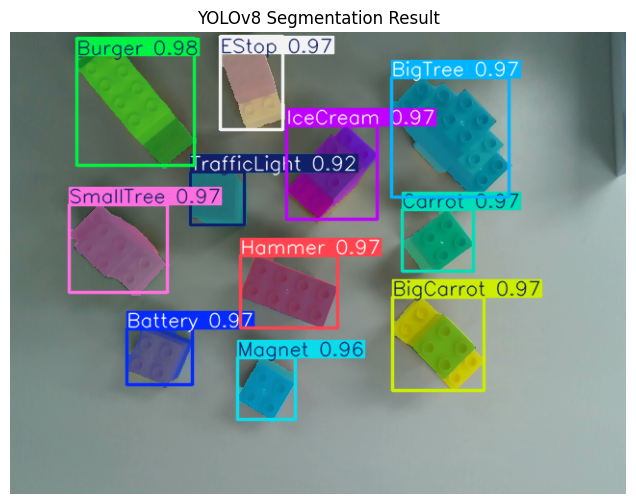

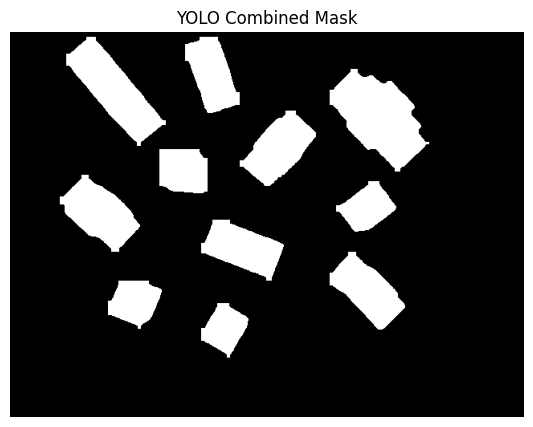

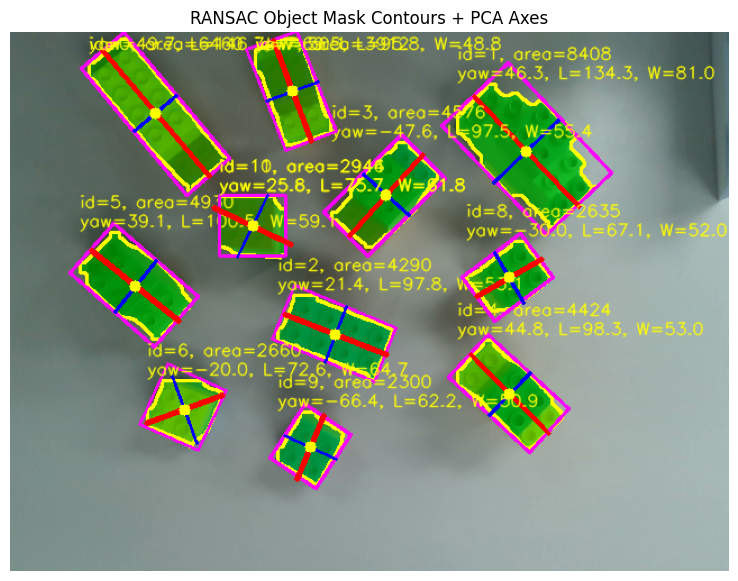

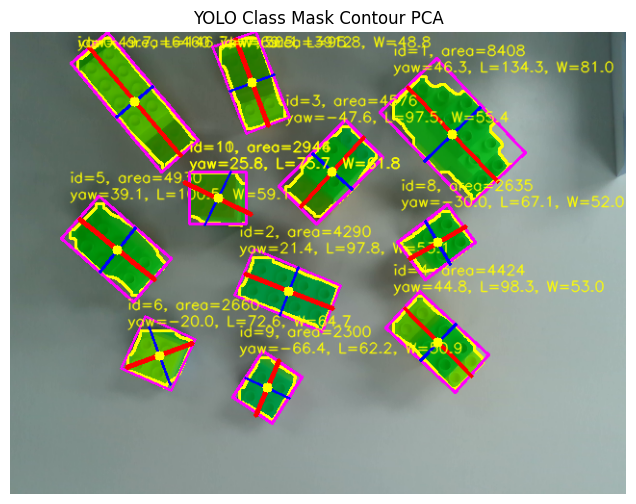


[YOLO Class Pose Table]
global 00 | local 00 | BigCarrot        | conf=0.97 | XYZ mm=(   79.9,    51.8,   409.5) | YAW=  44.84 | area=4424
global 01 | local 00 | IceCream         | conf=0.97 | XYZ mm=(    4.5,   -70.2,   413.4) | YAW= -47.64 | area=4576
global 02 | local 00 | Hammer           | conf=0.97 | XYZ mm=(  -27.0,    15.3,   421.1) | YAW=  21.37 | area=4290
global 03 | local 00 | BigTree          | conf=0.97 | XYZ mm=(   93.8,  -101.4,   426.4) | YAW=  46.30 | area=8408
global 04 | local 00 | Burger           | conf=0.98 | XYZ mm=( -137.9,  -120.2,   426.5) | YAW=  49.68 | area=6460
global 05 | local 00 | Carrot           | conf=0.97 | XYZ mm=(   83.8,   -20.6,   427.8) | YAW= -29.98 | area=2635
global 06 | local 00 | SmallTree        | conf=0.97 | XYZ mm=( -153.4,   -14.5,   431.3) | YAW=  39.12 | area=4930
global 07 | local 00 | Magnet           | conf=0.81 | XYZ mm=(  -80.5,   -53.3,   435.9) | YAW=  25.61 | area=2944
global 08 | local 00 | TrafficLight     | conf=0.92 | X

In [ ]:
import os
import yaml
import pprint
import glob
import cv2
import math

import torch
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO

import pyrealsense2 as rs
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import numpy as np
import copy

from scipy.spatial.transform import Rotation as R

import INUVisionLib as ivl

# 카메라 찾기
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 카메라 동작
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=False
)

V_visualize = True
mode = 'fine'
yolo_dir = "yolo_models/Component_Model_ver1.0/Model_s_ver2.0/best.pt"

pose_table, class_index = ivl.search_assembly(
    color_rgb=color_rgb,
    depth=depth,
    intrinsics=intrinsics,
    scale=scale,
    yolo_dir=yolo_dir,
    V_visualize=True,
    conf_thres=0.5,
    iou_thres=0.3,
    device=0
)

target_class = "Magnet"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "EStop"  
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "BigTree" 
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "IceCream" 
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "Burger" 
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "Carrot"    
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "TrafficLight"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "Hammer"  
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "BigCarrot" 
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "SmallTree"  
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)

target_class = "Battery"
X, Y, Z, YAW = ivl.get_target_grasp_pose(class_index, target_class)



# -------

In [ ]:
import os
import yaml
import pprint
import glob
import cv2
import math

import torch
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO

import pyrealsense2 as rs
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import numpy as np
import copy

from scipy.spatial.transform import Rotation as R

import INUVisionLib as ivl

# 카메라 찾기
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 카메라 동작
color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=False
)

def search_assembly(mode, yolo_dir, color_rgb, depth, intrinsics, scale, V_visualize=True):

    if mode not in ["coarse", "fine"]:
        raise ValueError(f"잘못된 mode 입력: {mode}. 'coarse' 또는 'fine'만 가능합니다.")

    if any(x is None for x in [color_rgb, depth, intrinsics, scale]):
        raise RuntimeError("RealSense 캡처 실패: 입력 데이터 중 None이 있습니다.")

    color_img_bgr = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2BGR)
    MODEL_PATH = os.path.join(yolo_dir)

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"YOLO model not found: {MODEL_PATH}")

    # 1. YOLO 디텍션 (0~10번, 총 11개 클래스 대응)
    model = YOLO(MODEL_PATH)
    target_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

    results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
        model=model, 
        color_img_bgr=color_img_bgr, 
        target_classes=target_classes, 
        visualize=V_visualize
    )

    # [NEW] YOLO 추론 결과를 필터링 없이 다이렉트로 final_objects 규격으로 변환
    final_objects = []
    img_h, img_w = color_img_bgr.shape[:2]

    if len(results) > 0 and results[0].masks is not None:
        boxes = results[0].boxes
        masks = results[0].masks.data.cpu().numpy()  # (N, H, W) PyTorch 텐서 -> 넘파이 변환
        class_ids = boxes.cls.cpu().numpy().astype(int)
        confidences = boxes.conf.cpu().numpy()
        class_names = results[0].names

        for i in range(len(masks)):
            # PyTorch 내부 규격의 마스크를 원본 카메라 해상도(img_w, img_h)로 칼같이 복원
            resized_mask = cv2.resize(
                masks[i], (img_w, img_h), interpolation=cv2.INTER_NEAREST
            ) > 0.5

            final_objects.append({
                "class_id": int(class_ids[i]),
                "class_name": class_names[class_ids[i]],
                "confidence": float(confidences[i]),
                "mask": resized_mask  # 뒷단이 제일 좋아하는 2차원 True/False 도화지
            })

    if V_visualize:
        print(f"[INFO] 억제 필터 생략 ➔ YOLO가 포착한 날것의 객체 {len(final_objects)}개 다이렉트 로드 완료.")

    # ============================================================
    # YOLO mask 후처리:
    # raw YOLO mask -> Opening -> Closing -> Convex Hull -> Dilation
    # ============================================================

    final_obj_fine = copy.deepcopy(final_objects)

    mask_yolo_raw_all = np.zeros(color_rgb.shape[:2], dtype=np.uint8)
    mask_openclose_all = np.zeros(color_rgb.shape[:2], dtype=np.uint8)
    mask_hull_all = np.zeros(color_rgb.shape[:2], dtype=np.uint8)
    mask_dilate_all = np.zeros(color_rgb.shape[:2], dtype=np.uint8)

    kernel_openclose = np.ones((3, 3), np.uint8)
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    for obj_idx, obj in enumerate(final_obj_fine):
        # 1. YOLO raw mask
        raw_mask = (np.asarray(obj["mask"]) > 0).astype(np.uint8) * 255

        # 2. Opening + Closing
        mask_open = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel_openclose)
        mask_close = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel_openclose)

        # 3. Convex Hull
        hull_mask = ivl.fill_object_mask_by_convex_hull(
            (mask_close > 0).astype(np.uint8),
            min_area=20
        ).astype(np.uint8) * 255

        # 4. Dilation / Padding
        dilated_mask = cv2.dilate(
            hull_mask,
            kernel_dilate,
            iterations=1
        )

        # 최종 mask를 final_obj_fine에 저장
        obj["mask_raw_yolo"] = raw_mask.astype(bool)
        obj["mask_openclose"] = (mask_close > 0)
        obj["mask_hull"] = (hull_mask > 0)
        obj["mask"] = (dilated_mask > 0)

        # 전체 마스크 합치기
        mask_yolo_raw_all = cv2.bitwise_or(mask_yolo_raw_all, raw_mask)
        mask_openclose_all = cv2.bitwise_or(mask_openclose_all, mask_close)
        # mask_hull_all = cv2.bitwise_or(mask_hull_all, hull_mask)
        # mask_dilate_all = cv2.bitwise_or(mask_dilate_all, dilated_mask)

    if V_visualize:
        print("[INFO] YOLO mask 후처리 완료")
        print(f" - raw yolo area      : {np.count_nonzero(mask_yolo_raw_all)} px")
        print(f" - open/close area    : {np.count_nonzero(mask_openclose_all)} px")
        # print(f" - convex hull area   : {np.count_nonzero(mask_hull_all)} px")
        # print(f" - dilation area      : {np.count_nonzero(mask_dilate_all)} px")

        plt.figure(figsize=(22, 6))

        plt.subplot(1, 5, 1)
        plt.imshow(color_rgb)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 5, 2)
        plt.imshow(mask_yolo_raw_all, cmap="gray", vmin=0, vmax=255)
        plt.title("1. Raw YOLO Mask")
        plt.axis("off")

        plt.subplot(1, 5, 3)
        plt.imshow(mask_openclose_all, cmap="gray", vmin=0, vmax=255)
        plt.title("2. Opening + Closing")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    # ====================================================================
    # 3. 마스터피스 도화지 생성 (RANSAC 10mm 바닥 컷 -> Bilateral -> LAB Otsu)
    # ====================================================================
    img_rgb = color_rgb.copy()

    xyz_map, valid_mask = ivl.depth_to_xyz_map(depth, scale, intrinsics)
    valid_points = xyz_map[valid_mask]

    best_plane, _ = ivl.fit_plane_ransac_numpy(valid_points, distance_threshold=0.006)
    dist_map = ivl.compute_plane_distance_map(xyz_map, valid_mask, best_plane)

    ransac_mask = (dist_map > 0.010).astype(np.uint8) * 255
    kernel_open = np.ones((9, 9), np.uint8)
    ransac_mask = cv2.morphologyEx(ransac_mask, cv2.MORPH_OPEN, kernel_open)
    ransac_mask = cv2.morphologyEx(ransac_mask, cv2.MORPH_CLOSE, kernel_open)
    ransac_mask = cv2.dilate(ransac_mask, np.ones((5, 5), np.uint8), iterations=1)
    # Convex Hull 들어가기 전 RANSAC Step 5 마스크 저장
    ransac_mask_step5 = ransac_mask.copy()

    # ============================================================
    # RANSAC Step5 mask 영역과 YOLO open/close mask 영역 IoU 비교
    # IoU >= 0.7인 RANSAC 영역만 유지
    # ============================================================

    iou_threshold = 0.7

    ransac_step5_255 = ((ransac_mask_step5 > 0).astype(np.uint8) * 255)
    openclose_255 = ((mask_openclose_all > 0).astype(np.uint8) * 255)

    # 크기 다르면 보정
    if openclose_255.shape != ransac_step5_255.shape:
        openclose_255 = cv2.resize(
            openclose_255,
            (ransac_step5_255.shape[1], ransac_step5_255.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )
        openclose_255 = ((openclose_255 > 0).astype(np.uint8) * 255)

    # RANSAC 영역 contour
    ransac_contours, _ = cv2.findContours(
        ransac_step5_255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # YOLO open/close 영역 contour
    openclose_contours, _ = cv2.findContours(
        openclose_255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    iou_filtered_mask = np.zeros_like(ransac_step5_255)

    for r_idx, r_cnt in enumerate(ransac_contours):
        if cv2.contourArea(r_cnt) < 100:
            continue

        r_mask = np.zeros_like(ransac_step5_255)
        cv2.drawContours(r_mask, [r_cnt], -1, 255, thickness=-1)

        best_iou = 0.0
        best_y_idx = -1

        for y_idx, y_cnt in enumerate(openclose_contours):
            if cv2.contourArea(y_cnt) < 100:
                continue

            y_mask = np.zeros_like(openclose_255)
            cv2.drawContours(y_mask, [y_cnt], -1, 255, thickness=-1)

            inter = np.logical_and(r_mask > 0, y_mask > 0)
            union = np.logical_or(r_mask > 0, y_mask > 0)

            union_area = np.count_nonzero(union)
            if union_area == 0:
                continue

            iou = np.count_nonzero(inter) / union_area

            if iou > best_iou:
                best_iou = iou
                best_y_idx = y_idx

        print(f"[IoU] RANSAC region {r_idx} | best YOLO region {best_y_idx} | IoU={best_iou:.3f}")

        if best_iou >= iou_threshold:
            cv2.drawContours(iou_filtered_mask, [r_cnt], -1, 255, thickness=-1)

    print(f"[INFO] IoU >= {iou_threshold} 영역만 남김")
    print(f" - RANSAC step5 area : {np.count_nonzero(ransac_step5_255)} px")
    print(f" - YOLO openclose    : {np.count_nonzero(openclose_255)} px")
    print(f" - IoU filtered area : {np.count_nonzero(iou_filtered_mask)} px")

    if V_visualize:
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(ransac_step5_255, cmap="gray", vmin=0, vmax=255)
        plt.title("RANSAC Step5 Mask")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(openclose_255, cmap="gray", vmin=0, vmax=255)
        plt.title("YOLO Opening + Closing Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(iou_filtered_mask, cmap="gray", vmin=0, vmax=255)
        plt.title(f"IoU Filtered Mask >= {iou_threshold}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    # ============================================================
    # IoU 필터 통과 영역 -> Convex Hull -> Dilation Padding
    # ============================================================

    # 1. Convex Hull
    iou_hull_mask = np.zeros_like(iou_filtered_mask)

    iou_contours, _ = cv2.findContours(
        iou_filtered_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in iou_contours:
        if cv2.contourArea(cnt) < 100:
            continue

        hull = cv2.convexHull(cnt)
        cv2.drawContours(iou_hull_mask, [hull], -1, 255, thickness=-1)

    # 2. Dilation Padding
    kernel_pad_iou = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    iou_hull_dilate_mask = cv2.dilate(
        iou_hull_mask,
        kernel_pad_iou,
        iterations=1
    )

    print("[INFO] IoU filtered 후처리 완료")
    print(f" - IoU filtered area   : {np.count_nonzero(iou_filtered_mask)} px")
    print(f" - Convex Hull area    : {np.count_nonzero(iou_hull_mask)} px")
    print(f" - Hull + Dilation area: {np.count_nonzero(iou_hull_dilate_mask)} px")


    if V_visualize:
        plt.figure(figsize=(24, 6))

        plt.subplot(1, 4, 1)
        plt.imshow(ransac_step5_255, cmap='gray', vmin=0, vmax=255)
        plt.title("1. RANSAC Step5 Mask")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(iou_filtered_mask, cmap='gray', vmin=0, vmax=255)
        plt.title("2. IoU Filtered Mask")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(iou_hull_mask, cmap='gray', vmin=0, vmax=255)
        plt.title("3. IoU + Convex Hull")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(iou_hull_dilate_mask, cmap='gray', vmin=0, vmax=255)
        plt.title("4. IoU + Hull + Dilation")
        plt.axis("off")

        plt.tight_layout()
        plt.show()




    # ============================================================
    # IoU + ConvexHull + Dilation 마스크를 최종 ROI 마스크로 사용
    # ============================================================

    final_iou_mask = ((iou_hull_dilate_mask > 0).astype(np.uint8) * 255)

    img_rgb_iou = color_rgb.copy()
    if img_rgb_iou.dtype != np.uint8:
        img_rgb_iou = np.clip(img_rgb_iou, 0, 255).astype(np.uint8)

    # 최종 마스크로 RGB 이미지 AND
    img_rgb_iou = cv2.bitwise_and(
        img_rgb_iou,
        img_rgb_iou,
        mask=final_iou_mask
    )


    if V_visualize:
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(color_rgb)
        plt.title("Original RGB")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(final_iou_mask, cmap="gray", vmin=0, vmax=255)
        plt.title("IoU + Hull + Dilation Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(img_rgb_iou)
        plt.title("RGB AND IoU Final Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


    filtered_rgb = cv2.bilateralFilter(img_rgb_iou, d=5, sigmaColor=50, sigmaSpace=50)
    lab = cv2.cvtColor(filtered_rgb, cv2.COLOR_RGB2LAB)
    _, a, b = cv2.split(lab)

    a_norm = cv2.normalize(cv2.absdiff(a, 128), None, 0, 255, cv2.NORM_MINMAX)
    b_norm = cv2.normalize(cv2.absdiff(b, 128), None, 0, 255, cv2.NORM_MINMAX)
    ab_combined = cv2.max(a_norm, b_norm)

    # ============================================================
    # Otsu 이진화 + final_iou_mask 제한 + Morphology
    # ============================================================

    _, binary_raw = cv2.threshold(
        ab_combined,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ROI 밖 제거
    binary_raw = cv2.bitwise_and(binary_raw, binary_raw, mask=final_iou_mask)

    kernel = np.ones((7, 7), np.uint8)

    binary_mask = cv2.morphologyEx(binary_raw, cv2.MORPH_OPEN, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    # morphology 이후에도 ROI 밖 제거
    binary_mask = cv2.bitwise_and(binary_mask, binary_mask, mask=final_iou_mask)

    # ============================================================
    # contour 추출 결과 시각화
    # ============================================================

    contours_all, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 1) 검정 배경 위에 contour만 보기
    contour_only_img = np.zeros((binary_mask.shape[0], binary_mask.shape[1], 3), dtype=np.uint8)

    # 2) 마스크된 RGB 위에 contour만 보기
    contour_on_rgb_img = img_rgb_iou.copy()

    valid_contours = []

    for i, cnt in enumerate(contours_all):
        area = cv2.contourArea(cnt)

        # 너무 작은 노이즈 제거
        if area < 100:
            continue

        valid_contours.append(cnt)

        # contour 그리기
        cv2.drawContours(contour_only_img, [cnt], -1, (0, 255, 0), 2)
        cv2.drawContours(contour_on_rgb_img, [cnt], -1, (255, 0, 0), 2)

        # 중심점 + 번호 표시
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            x, y, w, h = cv2.boundingRect(cnt)
            cx = x + w // 2
            cy = y + h // 2

        cv2.circle(contour_only_img, (cx, cy), 4, (255, 0, 0), -1)
        cv2.circle(contour_on_rgb_img, (cx, cy), 4, (255, 255, 0), -1)

        cv2.putText(
            contour_only_img,
            f"{i}",
            (cx - 10, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

        cv2.putText(
            contour_on_rgb_img,
            f"{i}",
            (cx - 10, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 0),
            1,
            cv2.LINE_AA
        )

    print(f"[INFO] 전체 contour 수: {len(contours_all)}")
    print(f"[INFO] area threshold 통과 contour 수: {len(valid_contours)}")


    if V_visualize:
        plt.figure(figsize=(18, 10))

        plt.subplot(2, 2, 1)
        plt.imshow(final_iou_mask, cmap="gray", vmin=0, vmax=255)
        plt.title("1. Final IoU Mask")
        plt.axis("off")

        plt.subplot(2, 2, 2)
        plt.imshow(binary_mask, cmap="gray", vmin=0, vmax=255)
        plt.title("2. Binary Mask")
        plt.axis("off")

        plt.subplot(2, 2, 3)
        plt.imshow(contour_only_img)
        plt.title("3. Contours Only")
        plt.axis("off")

        plt.subplot(2, 2, 4)
        plt.imshow(contour_on_rgb_img)
        plt.title("4. Contours on Masked RGB")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


    # ============================================================
    # Contour 별 PCA 결과 시각화
    # ============================================================

    contours_all, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    pca_result_img = img_rgb_iou.copy()
    pca_only_img = np.zeros((binary_mask.shape[0], binary_mask.shape[1], 3), dtype=np.uint8)

    pca_results = []

    min_area = 100

    for i, cnt in enumerate(contours_all):
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        # ------------------------------------------------------------
        # 중심점 계산
        # ------------------------------------------------------------
        M = cv2.moments(cnt)

        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            x, y, w, h = cv2.boundingRect(cnt)
            cx = x + w // 2
            cy = y + h // 2

        # ------------------------------------------------------------
        # PCA 계산
        # ------------------------------------------------------------
        pts = cnt.reshape(-1, 2).astype(np.float64)

        if len(pts) < 5:
            continue

        mean, eigenvectors = cv2.PCACompute(pts, mean=None)

        major_v = eigenvectors[0]   # 장축
        minor_v = eigenvectors[1]   # 단축

        # 장축 방향 고정: 위쪽(-Y)을 향하도록
        if major_v[1] > 0:
            major_v = -major_v

        # yaw 계산: 12시 방향 기준
        yaw_deg = math.degrees(math.atan2(major_v[0], -major_v[1]))
        yaw_deg = round(yaw_deg, 1)

        center = np.array([cx, cy], dtype=np.float64)

        major_len = 60
        minor_len = 35

        p_major_1 = center - major_v * major_len
        p_major_2 = center + major_v * major_len

        p_minor_1 = center - minor_v * minor_len
        p_minor_2 = center + minor_v * minor_len

        # ------------------------------------------------------------
        # 시각화: RGB 기준 색상
        # ------------------------------------------------------------
        # contour: 초록
        cv2.drawContours(pca_result_img, [cnt], -1, (0, 255, 0), 2)
        cv2.drawContours(pca_only_img, [cnt], -1, (0, 255, 0), 2)

        # 중심점: 빨강
        cv2.circle(pca_result_img, (cx, cy), 5, (255, 0, 0), -1)
        cv2.circle(pca_only_img, (cx, cy), 5, (255, 0, 0), -1)

        # 장축: 마젠타
        cv2.line(
            pca_result_img,
            tuple(p_major_1.astype(int)),
            tuple(p_major_2.astype(int)),
            (255, 0, 255),
            3
        )
        cv2.line(
            pca_only_img,
            tuple(p_major_1.astype(int)),
            tuple(p_major_2.astype(int)),
            (255, 0, 255),
            3
        )

        # 단축: 시안
        cv2.line(
            pca_result_img,
            tuple(p_minor_1.astype(int)),
            tuple(p_minor_2.astype(int)),
            (0, 255, 255),
            2
        )
        cv2.line(
            pca_only_img,
            tuple(p_minor_1.astype(int)),
            tuple(p_minor_2.astype(int)),
            (0, 255, 255),
            2
        )

        # 텍스트
        text = f"{len(pca_results)} | yaw {yaw_deg}deg"

        cv2.putText(
            pca_result_img,
            text,
            (cx - 45, cy - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 0),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            pca_only_img,
            text,
            (cx - 45, cy - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

        pca_results.append({
            "local_id": len(pca_results),
            "contour_index": i,
            "area_px": float(area),
            "cx": int(cx),
            "cy": int(cy),
            "yaw_deg": float(yaw_deg),
            "major_vector": major_v.tolist(),
            "minor_vector": minor_v.tolist()
        })

    print(f"[INFO] PCA 적용 contour 수: {len(pca_results)}")
    for item in pca_results:
        print(
            f"ID {item['local_id']} | "
            f"center=({item['cx']}, {item['cy']}) | "
            f"area={item['area_px']:.1f} | "
            f"yaw={item['yaw_deg']:.1f} deg"
        )

    if V_visualize:
        plt.figure(figsize=(18, 8))

        plt.subplot(1, 2, 1)
        plt.imshow(pca_only_img)
        plt.title("PCA Result Only")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(pca_result_img)
        plt.title("PCA Result on Masked RGB")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


    # ====================================================================
    # 4. final_obj_fine 기준:
    #    YOLO class 유지 + contour 추출 + moment + PCA + pose_table/class_index 생성
    # ====================================================================

    result_img = color_rgb.copy()
    pca_only_img = np.zeros((binary_mask.shape[0], binary_mask.shape[1], 3), dtype=np.uint8)

    fine_pose_table = []

    # ====================================================================
    # class별 pick 축 선택
    # "major" = PCA 장축 사용
    # "minor" = PCA 단축 사용
    # ====================================================================
    pick_axis_by_class = {
        "Battery": "major",
        "Magnet": "major",
        "EStop": "major",
        "Carrot": "major",
        "TrafficLight": "major",
        "SmallTree": "major",
        "Hammer": "major",
        "BigCarrot": "major",
        "Burger": "major",
        "IceCream": "major",
        "BigTree": "minor",
    }

    # ====================================================================
    # class별 색상 판별에 사용할 PCA 축
    # "major" = 장축 양끝 색상 확인
    # "minor" = 단축 양끝 색상 확인

    # 13: "Magnet",
    # 장축 파랑

    # 34: "Battery",
    # 장축 노랑

    # 241: "traffic light",
    # 장축 빨강

    # 442: "carrot",
    # 장축 초록

    # 462: "small tree",
    # 장축 초록

    # 711: "hammer",
    # 장축 파랑

    # 4482: "big carrot",
    # 장축 초록

    # 48132: "icecream"
    # 장축 초록

    # 81: "estop",
    # 단축 빨강

    # 8518: "burger",
    # 단축 노랑

    # 46262: "bigtree",
    # 단축 초록

    # ====================================================================
    color_axis_by_class = {
        "Battery": "major",
        "Magnet": "major",
        "EStop": "minor",
        "Carrot": "major",
        "TrafficLight": "major",
        "SmallTree": "major",
        "Hammer": "major",
        "BigCarrot": "major",
        "Burger": "minor",
        "IceCream": "major",
        "BigTree": "minor",
    }

    # 하단을 판정할 기준 색
    bottom_color_by_class = {
        "Battery": "yellow",
        "Magnet": "blue",
        "EStop": "red",
        "Carrot": "green",
        "TrafficLight": "red",
        "SmallTree": "green",
        "Hammer": "blue",
        "BigCarrot": "green",
        "Burger": "yellow",
        "IceCream": "green",
        "BigTree": "green",
    }

    min_area = 200

    for global_idx, obj in enumerate(final_obj_fine):
        raw_name = obj.get("class_name", "unknown")
        real_yolo_id = obj.get("class_id", obj.get("cls", global_idx))

        # ------------------------------------------------------------
        # 1. YOLO mask 가져오기
        # ------------------------------------------------------------
        yolo_mask_bool = np.asarray(obj["mask"], dtype=bool)

        # mask shape 보정
        if yolo_mask_bool.shape != binary_mask.shape:
            if yolo_mask_bool.shape[::-1] == binary_mask.shape:
                yolo_mask_bool = yolo_mask_bool.T
            else:
                yolo_mask_bool = cv2.resize(
                    yolo_mask_bool.astype(np.uint8),
                    (binary_mask.shape[1], binary_mask.shape[0]),
                    interpolation=cv2.INTER_NEAREST
                ).astype(bool)

            obj["mask"] = yolo_mask_bool

        # ------------------------------------------------------------
        # 2. YOLO mask 내부에서만 fine binary contour 사용
        # ------------------------------------------------------------
        local_mask = np.zeros_like(binary_mask, dtype=np.uint8)
        local_mask[yolo_mask_bool] = binary_mask[yolo_mask_bool]

        contours_local, _ = cv2.findContours(
            local_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours_local) == 0:
            print(f"[SKIP] {raw_name}: contour 없음")
            continue

        best_cnt = max(contours_local, key=cv2.contourArea)
        area = cv2.contourArea(best_cnt)

        if area < min_area:
            print(f"[SKIP] {raw_name}: area too small {area:.1f}")
            continue

        # ------------------------------------------------------------
        # 3. Moment 중심 계산
        # ------------------------------------------------------------
        M = cv2.moments(best_cnt)

        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            x, y, bw, bh = cv2.boundingRect(best_cnt)
            cx = x + bw // 2
            cy = y + bh // 2

        # depth 유효성 방어
        if not valid_mask[cy, cx]:
            print(f"[SKIP] {raw_name}: center depth invalid")
            continue

        # ------------------------------------------------------------
        # 4. PCA 계산
        # ------------------------------------------------------------
        pts = best_cnt.reshape(-1, 2).astype(np.float64)

        if len(pts) < 5:
            print(f"[SKIP] {raw_name}: PCA point 부족")
            continue

        mean, eigenvectors = cv2.PCACompute(pts, mean=None)

        major_v = eigenvectors[0].astype(np.float64)  # 장축
        minor_v = eigenvectors[1].astype(np.float64)  # 단축

        # 방향 안정화: 위쪽(-Y)을 향하도록
        if major_v[1] > 0:
            major_v = -major_v

        if minor_v[1] > 0:
            minor_v = -minor_v

        # 12시 방향 기준 yaw
        major_yaw_deg = math.degrees(math.atan2(major_v[0], -major_v[1]))
        minor_yaw_deg = math.degrees(math.atan2(minor_v[0], -minor_v[1]))

        major_yaw_deg = round(major_yaw_deg, 1)
        minor_yaw_deg = round(minor_yaw_deg, 1)

        # ------------------------------------------------------------
        # 5. class별 pick 축 선택
        # ------------------------------------------------------------
        pick_axis = pick_axis_by_class.get(raw_name, "major")

        if pick_axis == "major":
            pick_yaw_deg = major_yaw_deg
            pick_vector = major_v
        elif pick_axis == "minor":
            pick_yaw_deg = minor_yaw_deg
            pick_vector = minor_v
        else:
            raise ValueError(f"잘못된 pick_axis: {pick_axis}. major 또는 minor만 가능")

        # ------------------------------------------------------------
        # 선택 축 양끝 LAB 색상 분석
        # ------------------------------------------------------------
        color_axis = color_axis_by_class.get(raw_name, pick_axis)

        if color_axis == "major":
            color_axis_v = major_v
        elif color_axis == "minor":
            color_axis_v = minor_v
        else:
            raise ValueError(f"잘못된 color_axis: {color_axis}. major 또는 minor만 가능")

        axis_color_info = ivl.analyze_axis_end_colors(
            color_rgb=color_rgb,
            contour=best_cnt,
            center_xy=(cx, cy),
            axis_v=color_axis_v,
            radius_px=14,
            margin_px=12
        )

        bottom_color = bottom_color_by_class.get(raw_name, None)
        bottom_side = "unknown"

        if bottom_color is not None:
            bottom_proj_info = ivl.decide_bottom_side_by_color_projection(
                color_rgb=color_rgb,
                contour=best_cnt,
                center_xy=(cx, cy),
                axis_v=color_axis_v,
                bottom_color=bottom_color,
                min_pixels=30,
                side_gap_threshold=0.15,
                erode_px=3
            )

            bottom_side = bottom_proj_info["bottom_side"]

        else:
            bottom_proj_info = None
            bottom_side = "unknown"

        if axis_color_info is not None and bottom_color is not None:
            plus_ratio = axis_color_info["plus_color"]["ratio"].get(bottom_color, 0.0)
            minus_ratio = axis_color_info["minus_color"]["ratio"].get(bottom_color, 0.0)

            if plus_ratio > minus_ratio:
                bottom_side = "plus"
            elif minus_ratio > plus_ratio:
                bottom_side = "minus"

        # ------------------------------------------------------------
        # 6. 3D 좌표 계산
        # ------------------------------------------------------------
        x_m, y_m, top_z_m = xyz_map[cy, cx]

        h_mm = dist_map[cy, cx] * 1000.0
        center_z_mm = (top_z_m * 1000.0) + (h_mm / 2.0)

        axis_dist_m = float(np.sqrt(x_m**2 + y_m**2))

        # ------------------------------------------------------------
        # 7. pose item 생성
        # ------------------------------------------------------------
        item = {
            "global_idx": int(global_idx),
            "yolo_id": int(real_yolo_id),
            "class_name": raw_name,

            "axis_dist_m": float(axis_dist_m),
            "axis_dist_mm": float(axis_dist_m * 1000.0),

            "x_m": float(x_m),
            "y_m": float(y_m),
            "z_m": float(center_z_mm / 1000.0),

            "x_mm": float(x_m * 1000.0),
            "y_mm": float(y_m * 1000.0),
            "z_mm": float(center_z_mm),

            "pick_z_mm": float(top_z_m * 1000.0),

            # 최종 사용할 yaw
            "yaw_deg": float(pick_yaw_deg),
            "pick_yaw_deg": float(pick_yaw_deg),
            "pick_axis": pick_axis,

            # PCA 원본 결과
            "pca_major_yaw_deg": float(major_yaw_deg),
            "pca_minor_yaw_deg": float(minor_yaw_deg),
            "pca_major_vector": major_v.tolist(),
            "pca_minor_vector": minor_v.tolist(),
            "pick_vector": pick_vector.tolist(),

            "uv_center": (int(cx), int(cy)),
            "area_px": float(area),
            "contour": best_cnt,

            "color_axis": color_axis,
            "axis_end_plus_uv": axis_color_info["plus_uv"] if axis_color_info is not None else None,
            "axis_end_minus_uv": axis_color_info["minus_uv"] if axis_color_info is not None else None,
            "axis_plus_dominant_color": axis_color_info["plus_color"]["dominant"] if axis_color_info is not None else "unknown",
            "axis_minus_dominant_color": axis_color_info["minus_color"]["dominant"] if axis_color_info is not None else "unknown",
            "axis_plus_color_ratio": axis_color_info["plus_color"]["ratio"] if axis_color_info is not None else None,
            "axis_minus_color_ratio": axis_color_info["minus_color"]["ratio"] if axis_color_info is not None else None,

            "bottom_color": bottom_color,
            "bottom_side": bottom_side,

            "bottom_color_pixel_count": bottom_proj_info["target_pixel_count"] if bottom_proj_info is not None else 0,
            "bottom_plus_ratio": bottom_proj_info["plus_ratio"] if bottom_proj_info is not None else 0.0,
            "bottom_minus_ratio": bottom_proj_info["minus_ratio"] if bottom_proj_info is not None else 0.0,
            "bottom_color_centroid_uv": bottom_proj_info["target_centroid_uv"] if bottom_proj_info is not None else None,
        }



        obj["fine_pose"] = item
        fine_pose_table.append(item)

        # ------------------------------------------------------------
        # 8. 시각화
        # ------------------------------------------------------------
        center = np.array([cx, cy], dtype=np.float64)

        major_len = 60
        minor_len = 35

        p_major_1 = center - major_v * major_len
        p_major_2 = center + major_v * major_len

        p_minor_1 = center - minor_v * minor_len
        p_minor_2 = center + minor_v * minor_len

        # contour: 초록
        cv2.drawContours(result_img, [best_cnt], -1, (0, 255, 0), 2)
        cv2.drawContours(pca_only_img, [best_cnt], -1, (0, 255, 0), 2)

        # 중심점: 빨강
        cv2.circle(result_img, (cx, cy), 5, (255, 0, 0), -1)
        cv2.circle(pca_only_img, (cx, cy), 5, (255, 0, 0), -1)

        # 장축: 마젠타
        cv2.line(result_img, tuple(p_major_1.astype(int)), tuple(p_major_2.astype(int)), (255, 0, 255), 3)
        cv2.line(pca_only_img, tuple(p_major_1.astype(int)), tuple(p_major_2.astype(int)), (255, 0, 255), 3)

        # 단축: 시안
        cv2.line(result_img, tuple(p_minor_1.astype(int)), tuple(p_minor_2.astype(int)), (0, 255, 255), 2)
        cv2.line(pca_only_img, tuple(p_minor_1.astype(int)), tuple(p_minor_2.astype(int)), (0, 255, 255), 2)

        text = (
            f"ID:{real_yolo_id} {raw_name} | "
            f"{pick_axis} {pick_yaw_deg:.1f}d"
        )

        cv2.putText(
            result_img,
            text,
            (cx - 55, cy - 18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.43,
            (255, 255, 0),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            pca_only_img,
            f"{raw_name} | {pick_yaw_deg:.1f}d",
            (cx - 45, cy - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.43,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )
    
        if axis_color_info is not None:
            p_plus = axis_color_info["plus_uv"]
            p_minus = axis_color_info["minus_uv"]

            plus_dom = axis_color_info["plus_color"]["dominant"]
            minus_dom = axis_color_info["minus_color"]["dominant"]

            # plus endpoint: 흰색 원
            cv2.circle(result_img, p_plus, 7, (255, 255, 255), 2)
            cv2.putText(
                result_img,
                f"+:{plus_dom}",
                (p_plus[0] - 25, p_plus[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (255, 255, 255),
                1,
                cv2.LINE_AA
            )

            # minus endpoint: 노란색 원
            cv2.circle(result_img, p_minus, 7, (255, 255, 0), 2)
            cv2.putText(
                result_img,
                f"-:{minus_dom}",
                (p_minus[0] - 25, p_minus[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (255, 255, 0),
                1,
                cv2.LINE_AA
            )

            cv2.putText(
                result_img,
                f"bottom:{bottom_side}",
                (cx - 55, cy + 18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.42,
                (255, 255, 255),
                1,
                cv2.LINE_AA
            )

        if bottom_proj_info is not None and bottom_proj_info["target_centroid_uv"] is not None:
            bcx, bcy = bottom_proj_info["target_centroid_uv"]

            cv2.circle(result_img, (bcx, bcy), 8, (255, 255, 255), 2)

            cv2.putText(
                result_img,
                f"bottom:{bottom_side}",
                (bcx - 45, bcy - 12),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.42,
                (255, 255, 255),
                1,
                cv2.LINE_AA
            )

    # ====================================================================
    # 9. pose_table 정렬 + class_index 생성
    # ====================================================================

    fine_pose_table = sorted(
        fine_pose_table,
        key=lambda x: x["axis_dist_m"]
    )

    fine_class_index = {}

    for item in fine_pose_table:
        cls = item["class_name"]

        if cls not in fine_class_index:
            fine_class_index[cls] = []

        fine_class_index[cls].append(item)

    print("\n[FINE POSE TABLE]")
    for item in fine_pose_table:
        print(
            f"YOLO_ID {item['yolo_id']} | {item['class_name']} | "
            f"XYZ=({item['x_mm']:.1f}, {item['y_mm']:.1f}, {item['z_mm']:.1f}) mm | "
            f"pick_axis={item['pick_axis']} | "
            f"yaw={item['pick_yaw_deg']:.1f} | "
            f"major={item['pca_major_yaw_deg']:.1f} | "
            f"minor={item['pca_minor_yaw_deg']:.1f}"
        )

    print("\n[AXIS END COLOR RESULT]")
    for item in fine_pose_table:
        print(
            f"{item['class_name']} | "
            f"color_axis={item['color_axis']} | "
            f"+={item['axis_plus_dominant_color']} {item['axis_plus_color_ratio']} | "
            f"-={item['axis_minus_dominant_color']} {item['axis_minus_color_ratio']} | "
            f"bottom_color={item['bottom_color']} | "
            f"bottom_side={item['bottom_side']}"
        )

    print("\n[BOTTOM COLOR PROJECTION RESULT]")
    for item in fine_pose_table:
        print(
            f"{item['class_name']} | "
            f"axis={item['color_axis']} | "
            f"bottom_color={item['bottom_color']} | "
            f"side={item['bottom_side']} | "
            f"plus={item['bottom_plus_ratio']:.3f} | "
            f"minus={item['bottom_minus_ratio']:.3f} | "
            f"pixels={item['bottom_color_pixel_count']} | "
            f"centroid={item['bottom_color_centroid_uv']}"
        )

    print("\n[FINE CLASS INDEX]")
    for cls, items in fine_class_index.items():
        print(f" - {cls}: {len(items)}개")

    # ====================================================================
    # 10. 시각화
    # ====================================================================

    if V_visualize:
        cv2.drawMarker(
            result_img,
            (int(intrinsics.ppx), int(intrinsics.ppy)),
            (255, 255, 0),
            cv2.MARKER_CROSS,
            20,
            2
        )

        plt.figure(figsize=(18, 8))

        plt.subplot(1, 2, 1)
        plt.imshow(pca_only_img)
        plt.title("PCA Result Only")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(result_img)
        plt.title("PCA + YOLO Class + Pick Axis")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return fine_pose_table, fine_class_index



yolo_dir = 'yolo_models/Component_Model_ver1.0/Model_s_ver2.0/best.pt'
# mode = 'coarse'
mode = 'fine'
V_visualize = True
pose_table, class_index = search_assembly(mode, yolo_dir, color_rgb, depth, intrinsics, scale, V_visualize)



[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
🔥 센서 안정화 중... (10 프레임 대기)
✅ 카메라 스트리밍 안전 종료 완료.


NameError: name 'search_assembly' is not defined

#########################

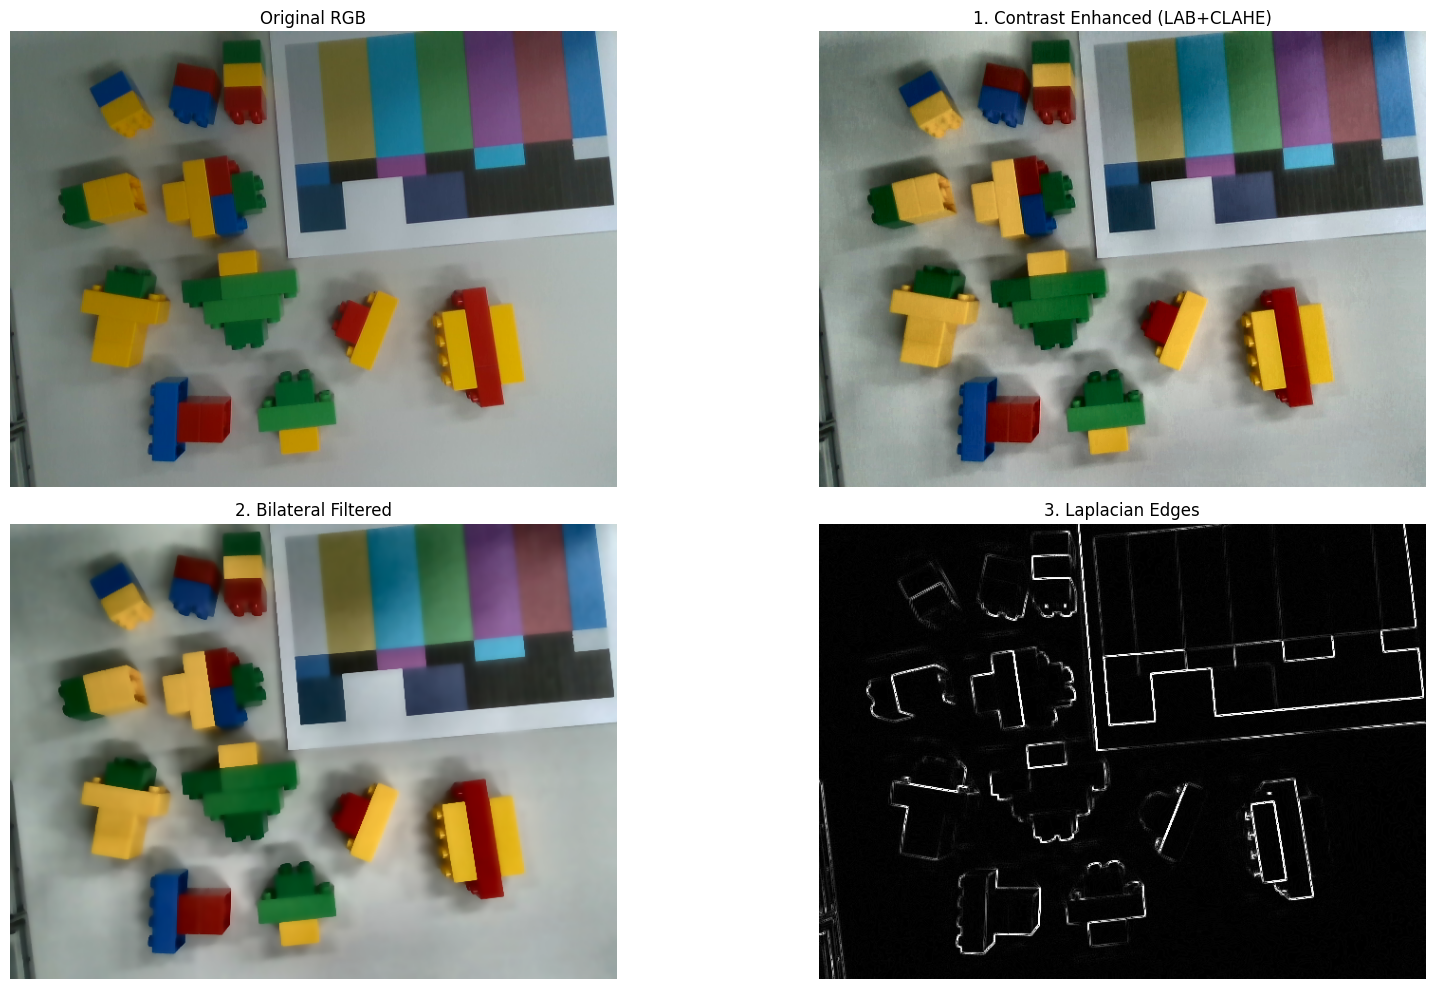

In [ ]:
##################################################################

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 로드 함수 (BGR로 읽어옴)
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        print("이미지를 불러오지 못했습니다. 경로를 확인해주세요.")
        return None
    # 시각화를 위해 RGB로 변환하여 반환
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1단계: 컬러 대비 증가 (LAB 색공간 + CLAHE)
def improve_color_contrast(img_rgb):
    # RGB -> LAB 변환
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # L 채널(밝기)에 CLAHE 적용 (지역적 대비 향상)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    # 채널 병합 및 LAB -> RGB 변환
    limg = cv2.merge((cl,a,b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

# 2단계: 양방향 필터 적용 (노이즈 제거, 엣지 보존)
def apply_bilateral_filter(img_rgb):
    # d=필터링 직경, sigmaColor=색상 공간 표준편차, sigmaSpace=좌표 공간 표준편차
    return cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)

# 3단계: 라플라시언 필터 적용 (2차 미분 기반 엣지 검출)
def apply_laplacian(img_rgb):
    # 라플라시언은 보통 그레이스케일 이미지에 적용하여 엣지를 확인합니다.
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    
    # cv2.CV_64F를 사용하여 부호 있는(signed) 데이터로 계산한 후
    laplacian_raw = cv2.Laplacian(img_gray, cv2.CV_64F, ksize=3)
    
    # 절대값을 취하고 0~255 범위로 정규화하여 엣지 강도를 시각화합니다.
    magnitude = cv2.normalize(cv2.convertScaleAbs(laplacian_raw), None, 0, 255, cv2.NORM_MINMAX)
    
    return magnitude

# ============================================================
# 이미지 로드 (이전 context의 color_rgb 이미지가 있다고 가정하거나 경로 지정)
# 예시 이미지가 없다면 cv2.imread('your_image.jpg') 등으로 직접 로드해야 합니다.
# 여기서는 이전 context에서 사용한 것처럼 color_rgb 변수가 정의되어 있다고 가정합니다.
# 직접 실행할 때는 아래 한 줄의 주석을 해제하고 실제 이미지 경로를 입력하세요.
# color_rgb = load_image('your_image.jpg') 
# ============================================================

# 이미지가 정상적으로 로드된 경우에만 실행
if 'color_rgb' in globals():
    original_img = color_rgb.copy()
    
    # 파이프라인 순차 적용
    contrast_img = improve_color_contrast(original_img)
    filtered_img = apply_bilateral_filter(contrast_img)
    laplacian_edges = apply_laplacian(filtered_img)
    
    # 시각화
    titles = ['Original RGB', '1. Contrast Enhanced (LAB+CLAHE)', '2. Bilateral Filtered', '3. Laplacian Edges']
    images = [original_img, contrast_img, filtered_img, laplacian_edges]
    

    
    plt.figure(figsize=(18, 10))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.title(titles[i])
        # Laplacian edges는 그레이스케일로 표시
        if i == 3:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("사용 가능한 'color_rgb' 이미지가 없습니다. 코드를 실행하기 전에 이미지를 로드해주세요.")

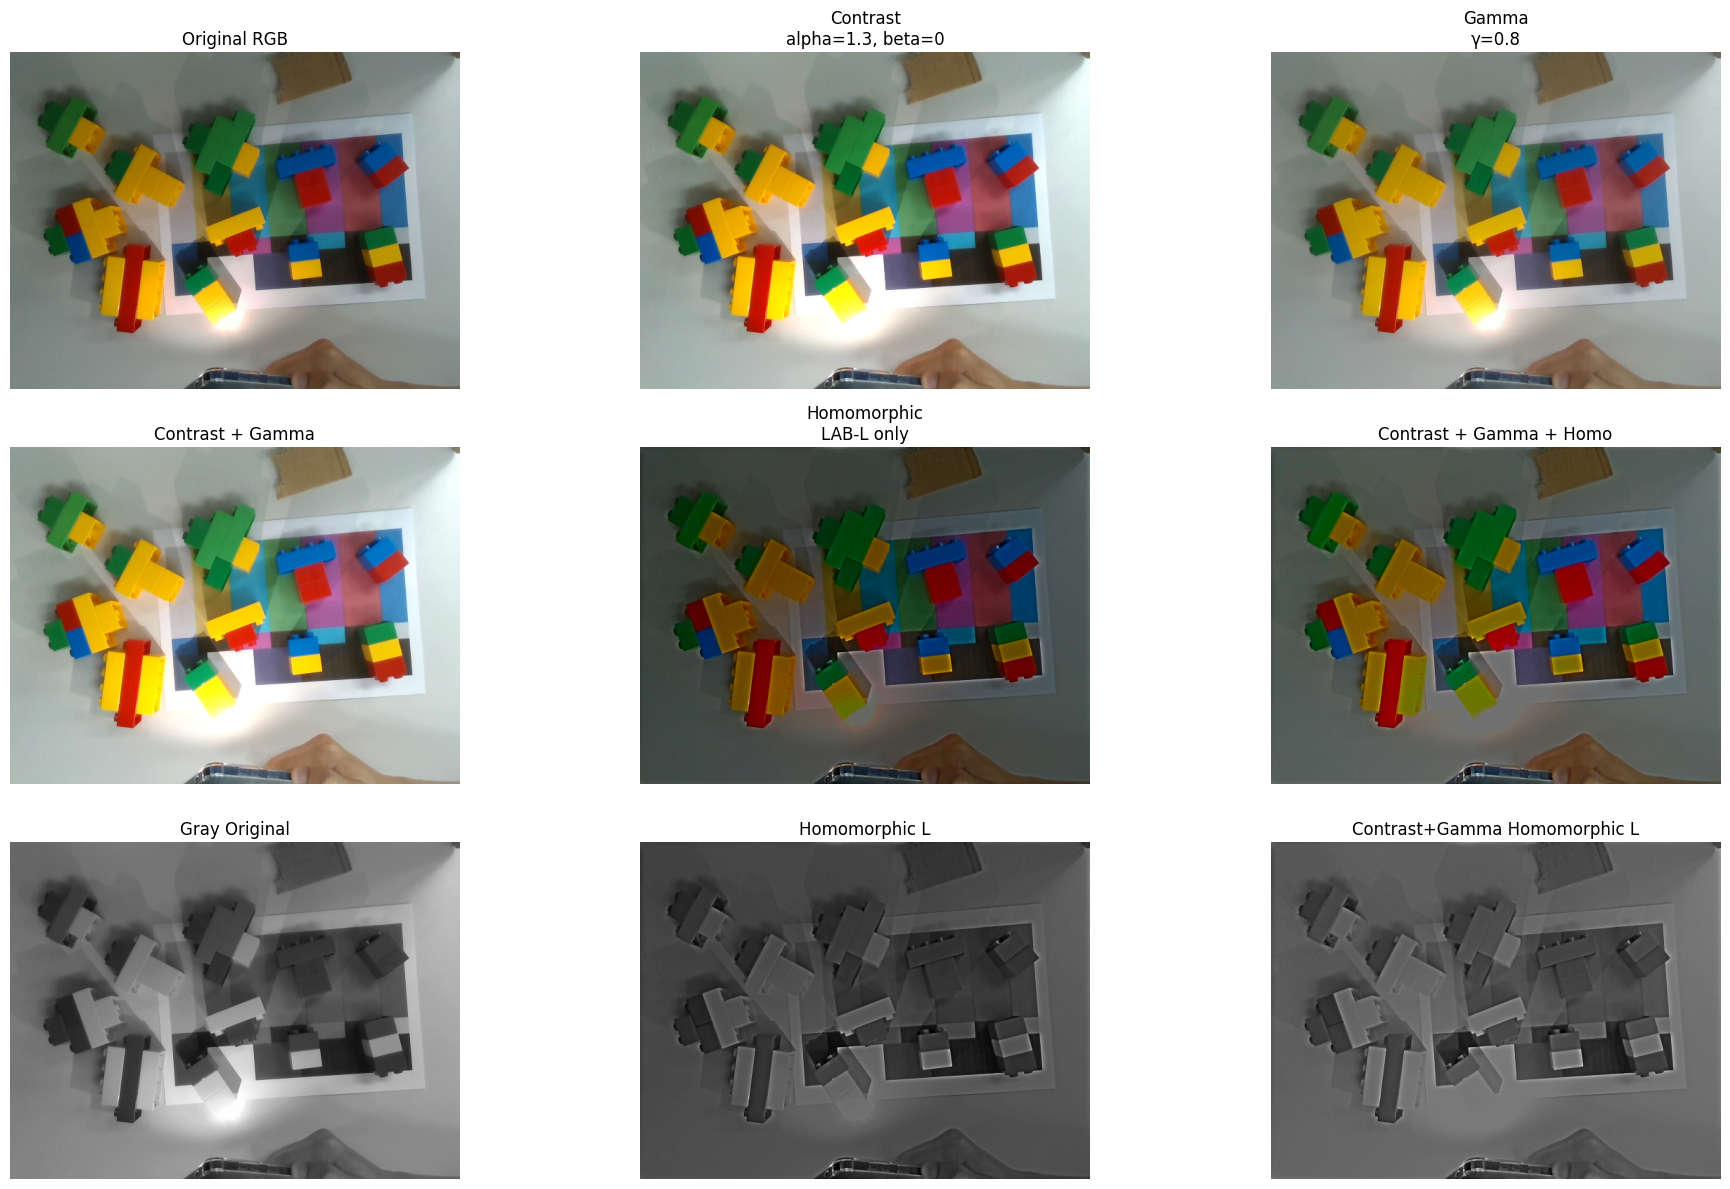

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# color_rgb 기준:
# 대비 보정 / 감마 보정 / Homomorphic Filter 비교
# ============================================================

img_rgb = color_rgb.copy()

if img_rgb.dtype != np.uint8:
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

# ------------------------------------------------------------
# 1. 대비 보정 함수
# alpha: 대비, beta: 밝기 offset
# ------------------------------------------------------------
def contrast_brightness(img, alpha=1.3, beta=0):
    out = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return out

# ------------------------------------------------------------
# 2. 감마 보정 함수
# gamma < 1 : 어두운 영역 밝게
# gamma > 1 : 밝은 영역 억제 / 전체 어둡게
# ------------------------------------------------------------
def gamma_correction(img, gamma=0.8):
    img_float = img.astype(np.float32) / 255.0
    out = np.power(img_float, gamma)
    out = np.clip(out * 255.0, 0, 255).astype(np.uint8)
    return out

# ------------------------------------------------------------
# 3. Homomorphic Filter
# 조명 성분 저주파 제거 + 반사 성분 고주파 강조
# 보통 grayscale/L 채널에 적용하는 게 안정적
# ------------------------------------------------------------
def homomorphic_filter_gray(
    gray,
    gamma_l=0.6,
    gamma_h=1.6,
    c=1.0,
    d0=30
):
    gray = gray.astype(np.float32)

    # log 변환
    img_log = np.log1p(gray)

    # FFT
    rows, cols = gray.shape
    fft = np.fft.fft2(img_log)
    fft_shift = np.fft.fftshift(fft)

    # 주파수 거리 맵
    y, x = np.indices((rows, cols))
    cy, cx = rows // 2, cols // 2
    d2 = (x - cx) ** 2 + (y - cy) ** 2

    # Gaussian High-pass 기반 Homomorphic filter
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * d2 / (d0 ** 2))) + gamma_l

    # 필터 적용
    filtered_shift = H * fft_shift
    filtered = np.fft.ifftshift(filtered_shift)
    img_back = np.fft.ifft2(filtered)
    img_back = np.real(img_back)

    # exp 복원
    img_exp = np.expm1(img_back)

    # 정규화
    img_norm = cv2.normalize(img_exp, None, 0, 255, cv2.NORM_MINMAX)
    img_norm = np.clip(img_norm, 0, 255).astype(np.uint8)

    return img_norm

# ------------------------------------------------------------
# 4. LAB L 채널 기반 Homomorphic RGB 복원
# ------------------------------------------------------------
def homomorphic_filter_rgb_by_lab_l(
    img_rgb,
    gamma_l=0.6,
    gamma_h=1.6,
    c=1.0,
    d0=30
):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    L_homo = homomorphic_filter_gray(
        L,
        gamma_l=gamma_l,
        gamma_h=gamma_h,
        c=c,
        d0=d0
    )

    lab_homo = cv2.merge([L_homo, A, B])
    rgb_homo = cv2.cvtColor(lab_homo, cv2.COLOR_LAB2RGB)

    return rgb_homo, L_homo

# ============================================================
# 파라미터
# ============================================================

alpha = 1.3      # 대비. 1.0보다 크면 대비 증가
beta = 0         # 밝기 offset
gamma = 0.8      # 0.7~0.9 추천. <1이면 어두운 부분 밝아짐

gamma_l = 0.6    # 저주파 조명 성분 억제 정도
gamma_h = 1.6    # 고주파 디테일 강조 정도
c = 1.0
d0 = 35          # 작을수록 조명 변화 제거 강함, 클수록 부드러움

# ============================================================
# 처리
# ============================================================

# 원본 gray/L
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 대비 보정
img_contrast = contrast_brightness(img_rgb, alpha=alpha, beta=beta)

# 감마 보정
img_gamma = gamma_correction(img_rgb, gamma=gamma)

# 대비 + 감마
img_contrast_gamma = gamma_correction(img_contrast, gamma=gamma)

# Homomorphic filter
img_homo, L_homo = homomorphic_filter_rgb_by_lab_l(
    img_rgb,
    gamma_l=gamma_l,
    gamma_h=gamma_h,
    c=c,
    d0=d0
)

# 대비 + 감마 + Homomorphic filter
img_cg_homo, L_cg_homo = homomorphic_filter_rgb_by_lab_l(
    img_contrast_gamma,
    gamma_l=gamma_l,
    gamma_h=gamma_h,
    c=c,
    d0=d0
)

# ============================================================
# 시각화
# ============================================================

imgs = [
    ("Original RGB", img_rgb, None),
    (f"Contrast\nalpha={alpha}, beta={beta}", img_contrast, None),
    (f"Gamma\nγ={gamma}", img_gamma, None),
    ("Contrast + Gamma", img_contrast_gamma, None),
    ("Homomorphic\nLAB-L only", img_homo, None),
    ("Contrast + Gamma + Homo", img_cg_homo, None),
    ("Gray Original", gray, "gray"),
    ("Homomorphic L", L_homo, "gray"),
    ("Contrast+Gamma Homomorphic L", L_cg_homo, "gray"),
]

plt.figure(figsize=(20, 12))

for i, (title, im, cmap) in enumerate(imgs):
    plt.subplot(3, 3, i + 1)
    plt.title(title)

    if cmap == "gray":
        plt.imshow(im, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(im)

    plt.axis("off")

plt.tight_layout()
plt.show()

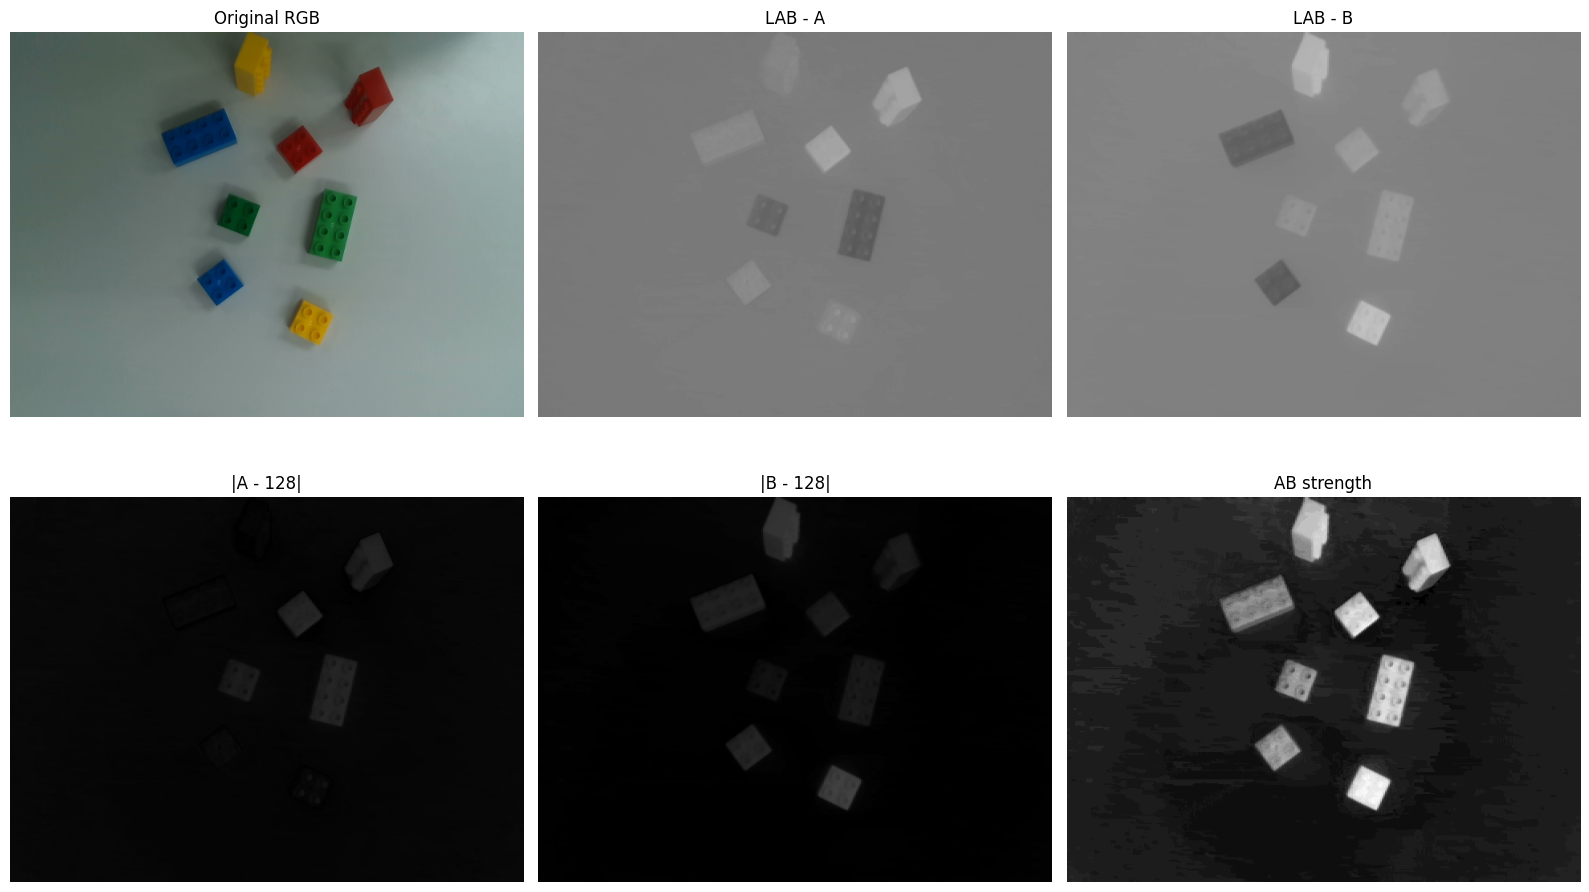

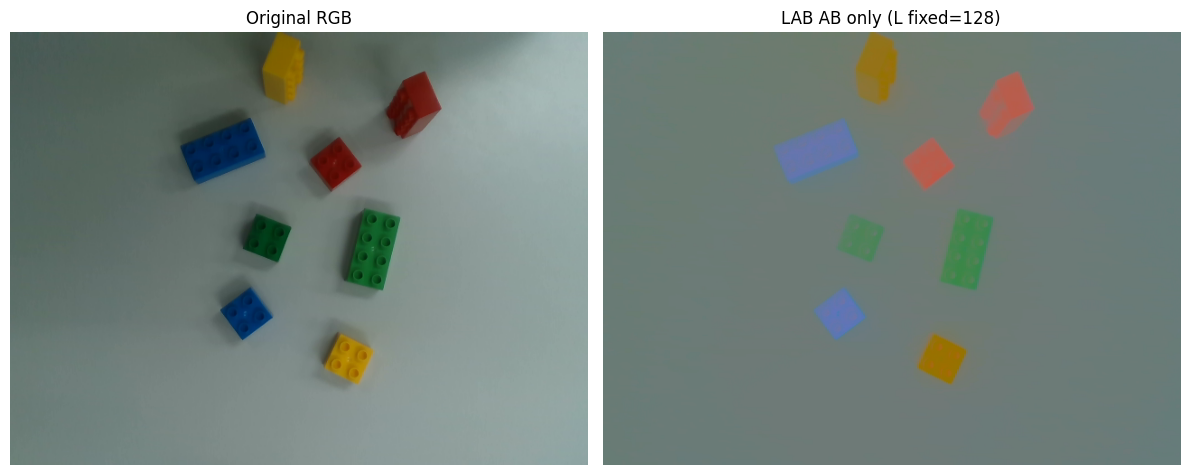

NameError: name 'ab_mask' is not defined

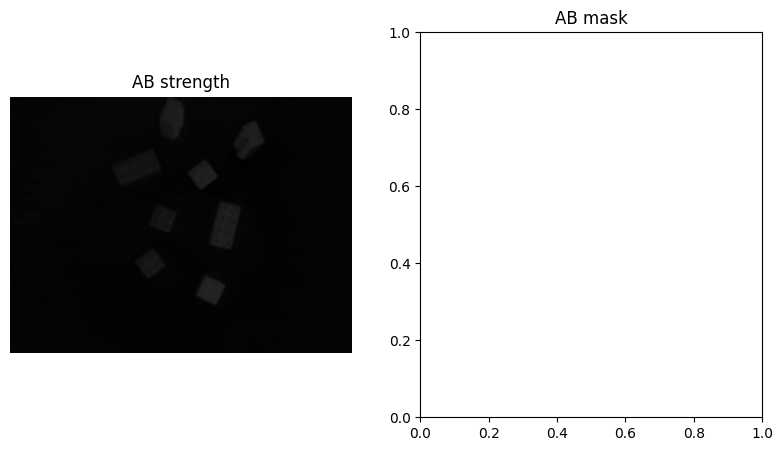

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# color_rgb 기준: LAB에서 L 제외, A/B만 보기
# ============================================================

img_rgb = color_rgb.copy()

if img_rgb.dtype != np.uint8:
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

# RGB -> LAB
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(lab)

# OpenCV LAB에서 A,B는 128이 중립값
# 128에서 멀수록 "색 성분"이 강하다고 볼 수 있음
A_diff = cv2.absdiff(A, np.full_like(A, 128))
B_diff = cv2.absdiff(B, np.full_like(B, 128))

# A/B 색차 강도
AB_strength = cv2.addWeighted(A_diff, 0.5, B_diff, 0.5, 0)
AB_strength = cv2.normalize(AB_strength, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(16, 10))

images = [
    ("Original RGB", img_rgb, None),
    ("LAB - A", A, "gray"),
    ("LAB - B", B, "gray"),
    ("|A - 128|", A_diff, "gray"),
    ("|B - 128|", B_diff, "gray"),
    ("AB strength", AB_strength, "gray"),
]

for i, (title, img, cmap) in enumerate(images):
    plt.subplot(2, 3, i + 1)
    plt.title(title)
    if cmap == "gray":
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LAB에서 L을 고정하고 A/B만 남긴 RGB 시각화
# ============================================================

img_rgb = color_rgb.copy()

if img_rgb.dtype != np.uint8:
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(lab)

# L을 고정값으로 설정
# 128: 중간 밝기
L_fixed = np.full_like(L, 128)

# A/B만 유지
lab_ab_only = cv2.merge([L_fixed, A, B])

# 다시 RGB로 변환
rgb_ab_only = cv2.cvtColor(lab_ab_only, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original RGB")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("LAB AB only (L fixed=128)")
plt.imshow(rgb_ab_only)
plt.axis("off")

plt.tight_layout()
plt.show()

import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb = color_rgb.copy()

if img_rgb.dtype != np.uint8:
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(lab)

A_diff = cv2.absdiff(A, np.full_like(A, 128))
B_diff = cv2.absdiff(B, np.full_like(B, 128))

# 색차 강도
AB_strength = cv2.addWeighted(A_diff, 0.5, B_diff, 0.5, 0)
AB_strength = cv2.GaussianBlur(AB_strength, (5, 5), 0)

# threshold
_, ab_mask = cv2.threshold(AB_strength, 20, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("AB strength")
plt.imshow(AB_strength, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("AB mask")
plt.imshow(ab_mask, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Mask overlay")
overlay = img_rgb.copy()
overlay[ab_mask == 0] = 0
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

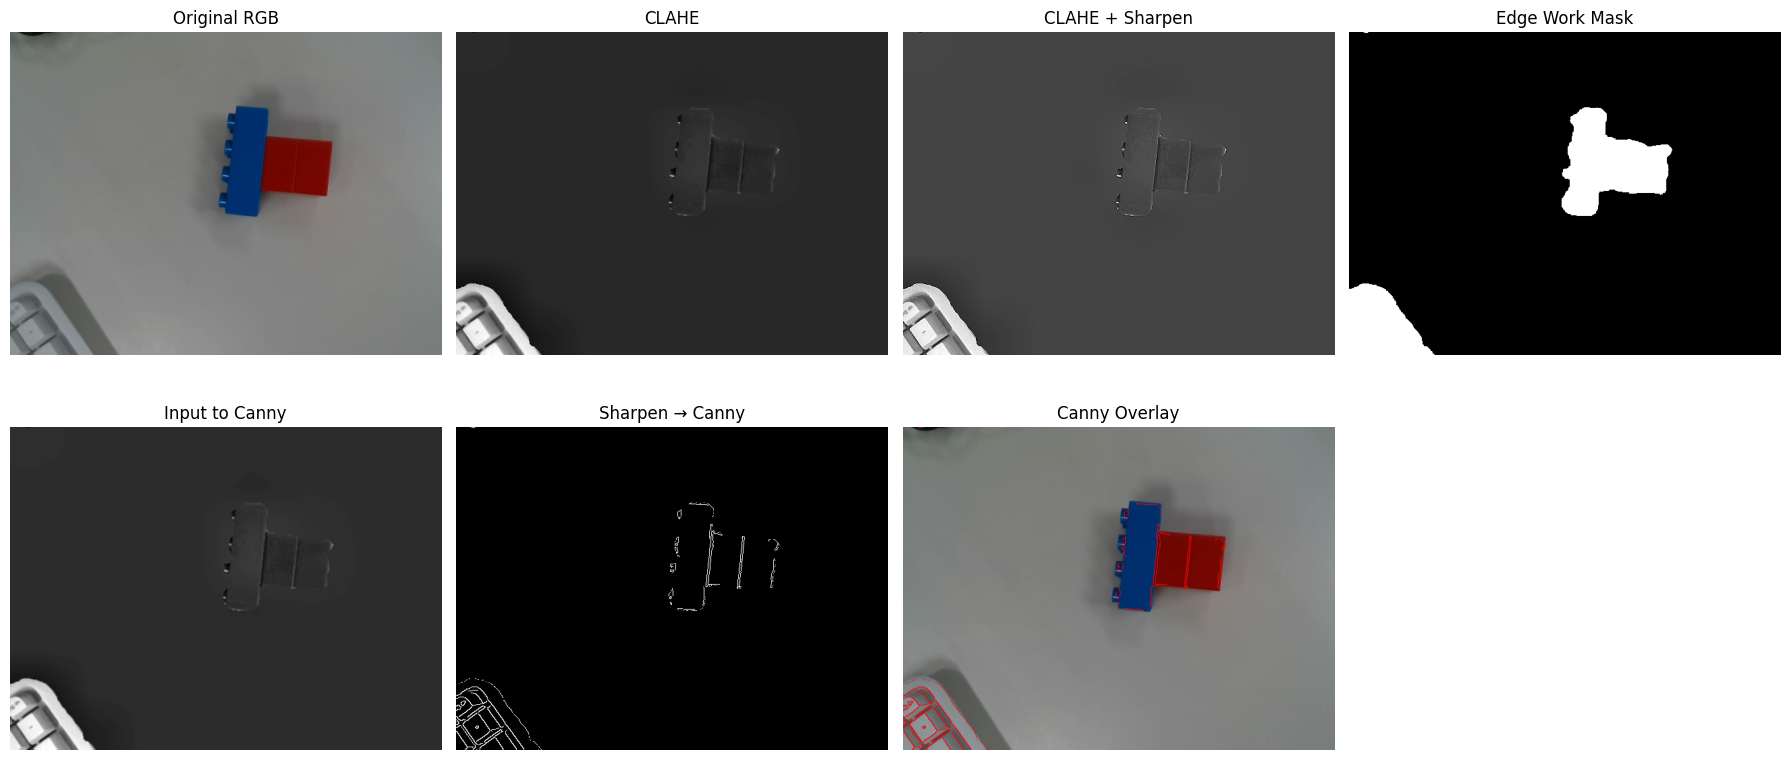

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RANSAC object mask 영역 안에서만
# Gray → outside fill → Median → CLAHE → Sharpen → Canny
# ============================================================

ransac_object_mask = (result["object_mask"] > 0).astype(np.uint8) * 255


gray_plain = cv2.cvtColor(color_img_rgb, cv2.COLOR_RGB2GRAY)

alpha_gray = 1.6
beta_gray = 0

gray_contrast = cv2.convertScaleAbs(
    gray_plain,
    alpha=alpha_gray,
    beta=beta_gray
)

# ------------------------------------------------------------
# 0. 마스크 살짝 erode
# ------------------------------------------------------------
erode_kernel = np.ones((3, 3), np.uint8)
edge_work_mask = cv2.erode(ransac_object_mask, erode_kernel, iterations=1)

# ------------------------------------------------------------
# 1. 마스크 바깥을 내부 median 값으로 채움
# ------------------------------------------------------------
inside_pixels = gray_contrast[edge_work_mask > 0]

if inside_pixels.size > 0:
    fill_value = int(np.median(inside_pixels))
else:
    fill_value = 0

gray_filled = gray_contrast.copy()
gray_filled[edge_work_mask == 0] = fill_value

# ------------------------------------------------------------
# 2. 약한 median
# ------------------------------------------------------------
gray_median = cv2.medianBlur(gray_filled, 3)

# ------------------------------------------------------------
# 3. CLAHE
# ------------------------------------------------------------
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
gray_clahe = clahe.apply(gray_median)

# ------------------------------------------------------------
# 4. 약한 sharpening
# ------------------------------------------------------------
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

gray_sharp = cv2.filter2D(gray_clahe, -1, sharpen_kernel)

# ============================================================
# A. Sharpen 다음 Scharr 대신 Canny
# ============================================================

# Canny는 노이즈에 민감해서 blur 권장
gray_for_canny = cv2.GaussianBlur(gray_sharp, (5, 5), 0)
# 얇은 선 더 살리고 싶으면 아래 사용
# gray_for_canny = cv2.GaussianBlur(gray_sharp, (3, 3), 0)
# gray_for_canny = gray_sharp

canny_edges = cv2.Canny(
    gray_for_canny,
    threshold1=20,
    threshold2=80
)

# RANSAC 내부만 유지
canny_edges = cv2.bitwise_and(canny_edges, canny_edges, mask=edge_work_mask)

# ------------------------------------------------------------
# 기존 뒤쪽 코드와 호환되도록 변수명 맞춤
# 이제 scharr_binary라는 이름이지만 실제 내용은 Canny edge임
# ------------------------------------------------------------
scharr_binary = canny_edges.copy()

# ============================================================
# D. 보기 좋게 원본 위에 edge overlay
# ============================================================

def make_edge_overlay(rgb_img, edge_mask, edge_color=(255, 0, 0)):
    overlay = rgb_img.copy()
    edge_bool = edge_mask > 0
    overlay[edge_bool] = edge_color
    return overlay

canny_overlay = make_edge_overlay(color_img_rgb, canny_edges, edge_color=(255, 0, 0))




# ============================================================
# E. 시각화
# ============================================================

plt.figure(figsize=(18, 12))

plt.subplot(3, 4, 1)
plt.imshow(color_img_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(gray_clahe, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(gray_sharp, cmap="gray")
plt.title("CLAHE + Sharpen")
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(edge_work_mask, cmap="gray")
plt.title("Edge Work Mask")
plt.axis("off")

plt.subplot(3, 4, 5)
plt.imshow(gray_for_canny, cmap="gray")
plt.title("Input to Canny")
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(canny_edges, cmap="gray")
plt.title("Sharpen → Canny")
plt.axis("off")

plt.subplot(3, 4, 7)
plt.imshow(canny_overlay)
plt.title("Canny Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

[INFO] 분리된 영역 개수: 6
Region 0: area=720, bbox=(13, 428, 34, 37), center=(29.845833333333335, 446.18333333333334)
Region 1: area=371, bbox=(36, 420, 26, 28), center=(48.3800539083558, 434.1698113207547)
Region 2: area=347, bbox=(62, 455, 25, 25), center=(72.93659942363112, 468.342939481268)
Region 3: area=293, bbox=(37, 465, 30, 15), center=(52.720136518771334, 473.8839590443686)
Region 4: area=250, bbox=(10, 393, 25, 19), center=(22.744, 401.976)
Region 5: area=211, bbox=(0, 458, 14, 22), center=(5.0663507109004735, 470.8483412322275)


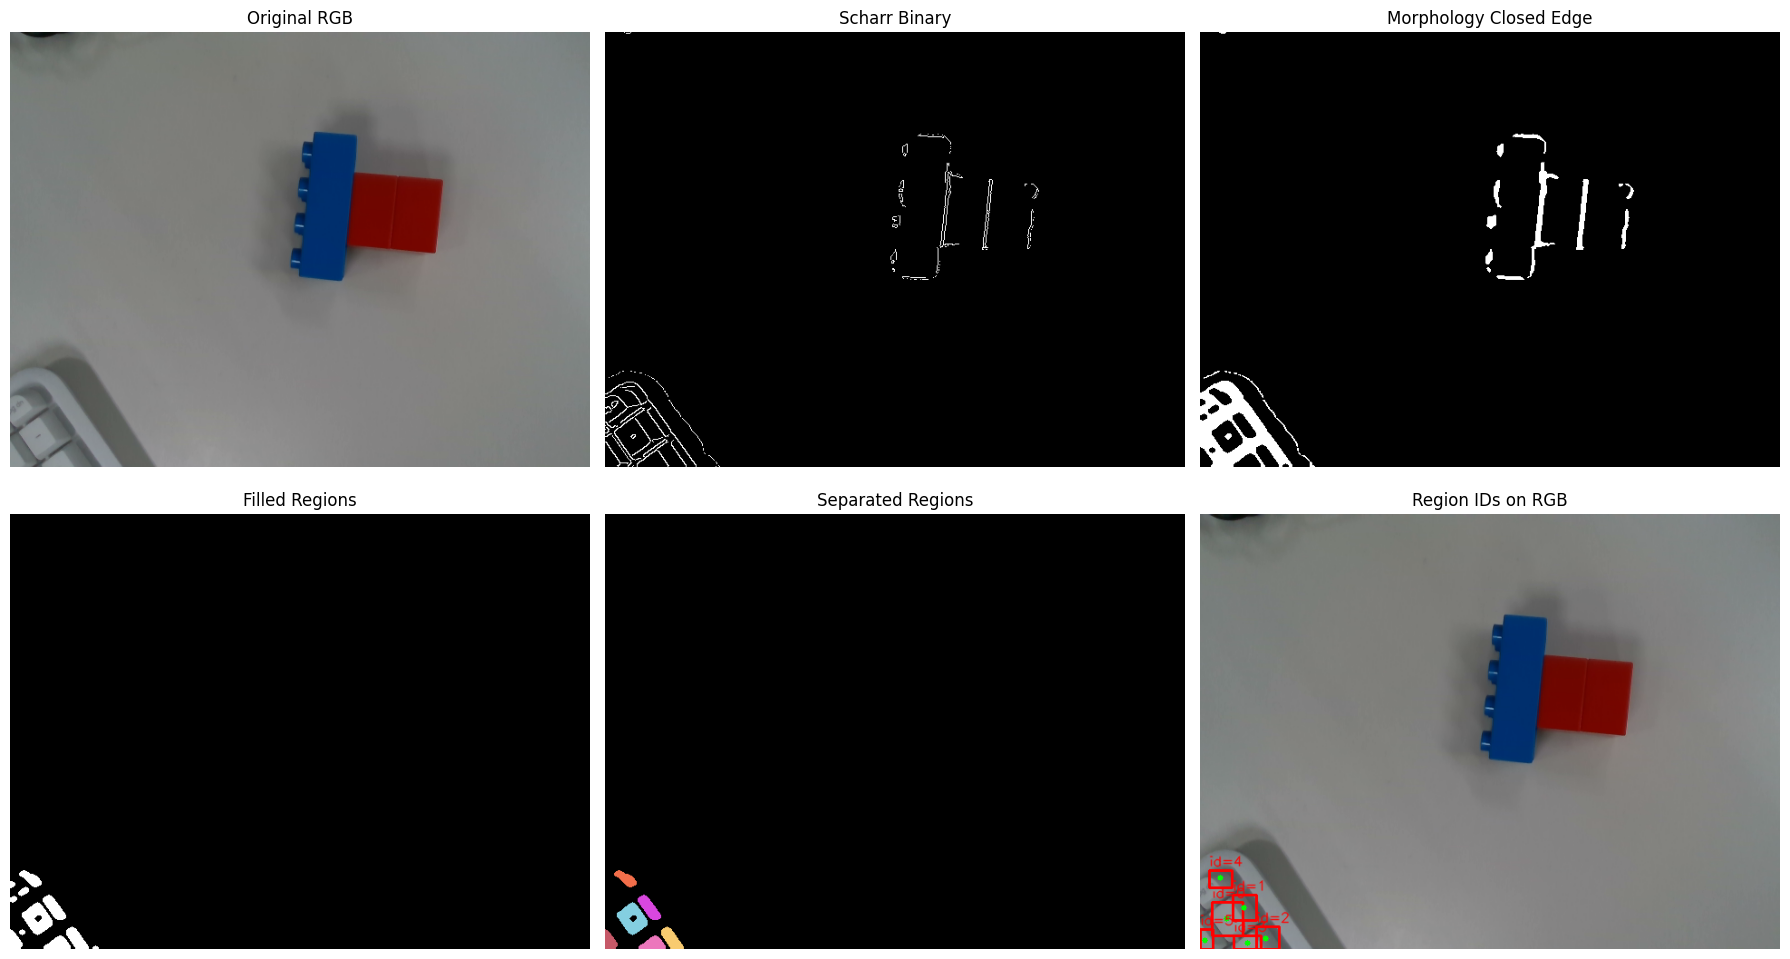

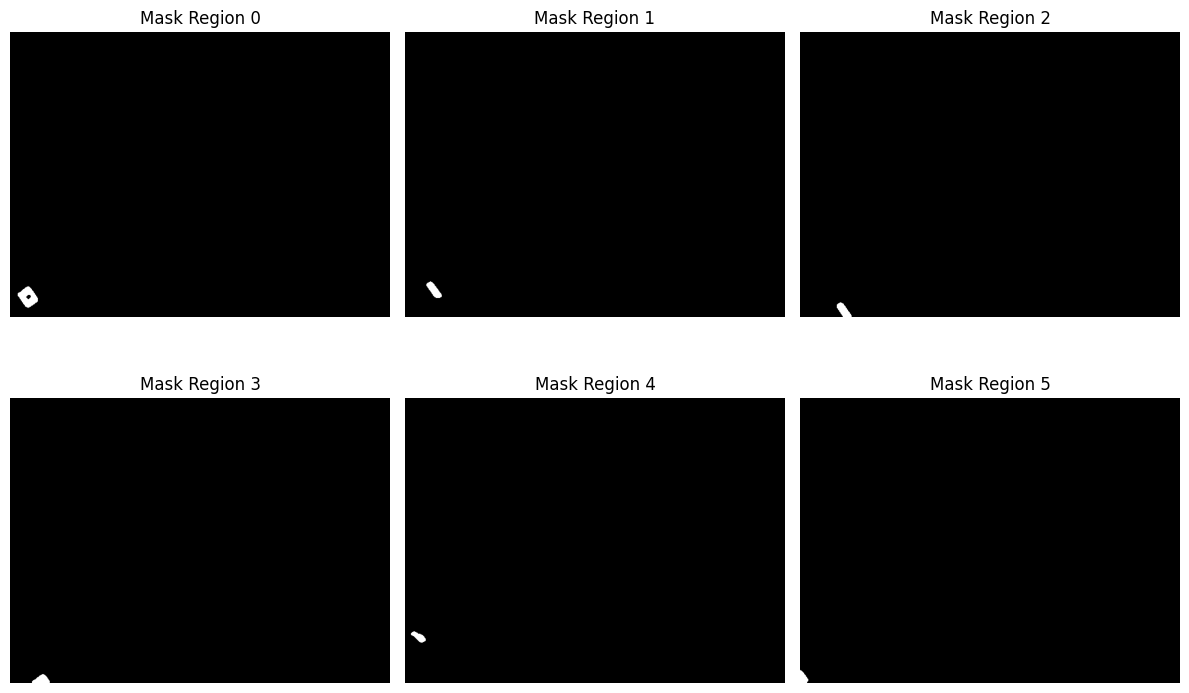

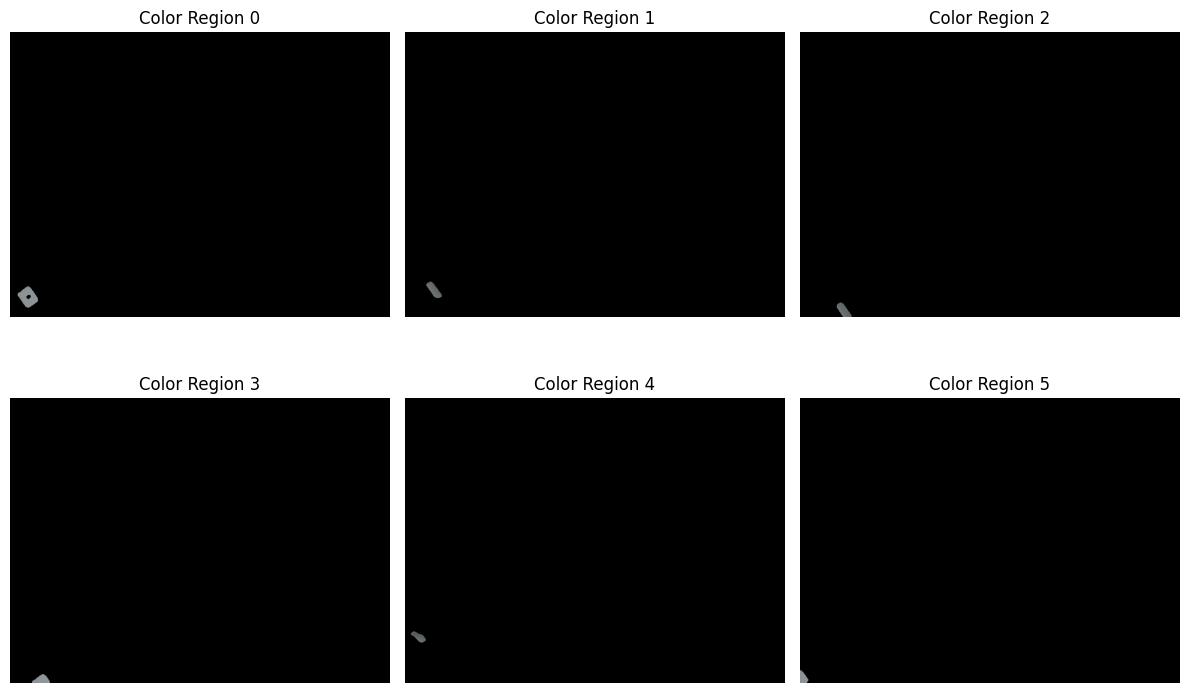

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# 1. scharr binary에서 끊긴 선 이어주기
# ============================================================

edge_bin = (scharr_binary > 0).astype(np.uint8) * 255

# ---- 튜닝 포인트 ----
close_ksize = 5       # 선 끊김이 많으면 5~7
close_iter = 2        # 1~3
dilate_ksize = 3      # 선을 조금 두껍게
dilate_iter = 1       # 너무 크면 영역이 합쳐질 수 있음
min_region_area = 150 # 작은 잡영 제거용

kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_ksize, dilate_ksize))
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# 끊긴 선 이어주기
edge_closed = cv2.morphologyEx(edge_bin, cv2.MORPH_CLOSE, kernel_close, iterations=close_iter)

# 선을 약간 두껍게 해서 내부가 잘 닫히도록
edge_closed = cv2.dilate(edge_closed, kernel_dilate, iterations=dilate_iter)

# 유효 mask 내부만 유지
edge_closed = cv2.bitwise_and(edge_closed, edge_closed, mask=edge_work_mask)

# ============================================================
# 2. 닫힌 선 내부 영역 채우기
#    flood fill로 바깥 배경을 채운 뒤 반전해서 내부 영역만 얻음
# ============================================================

h, w = edge_closed.shape[:2]

flood_img = edge_closed.copy()
flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)

# 바깥 배경을 흰색으로 flood fill
cv2.floodFill(flood_img, flood_mask, seedPoint=(0, 0), newVal=255)

# 반전하면 "닫힌 경계 내부"가 흰색이 됨
filled_regions = cv2.bitwise_not(flood_img)

# 유효 mask 내부만 유지
filled_regions = cv2.bitwise_and(filled_regions, filled_regions, mask=edge_work_mask)

# 노이즈 정리
filled_regions = cv2.morphologyEx(filled_regions, cv2.MORPH_OPEN, kernel_open, iterations=1)

# ============================================================
# 3. 영역 분리 (Connected Components)
# ============================================================

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    (filled_regions > 0).astype(np.uint8),
    connectivity=8
)

piece_masks = []
piece_color_images = []
piece_infos = []

for label_id in range(1, num_labels):  # 0은 background
    area = stats[label_id, cv2.CC_STAT_AREA]

    if area < min_region_area:
        continue

    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    ww = stats[label_id, cv2.CC_STAT_WIDTH]
    hh = stats[label_id, cv2.CC_STAT_HEIGHT]
    cx, cy = centroids[label_id]

    single_mask = np.zeros_like(filled_regions, dtype=np.uint8)
    single_mask[labels == label_id] = 255

    # 해당 조각만 남기고 나머지는 검정
    single_color = cv2.bitwise_and(color_img_rgb, color_img_rgb, mask=single_mask)

    piece_masks.append(single_mask)
    piece_color_images.append(single_color)
    piece_infos.append({
        "label_id": label_id,
        "area_px": int(area),
        "bbox_xywh": (int(x), int(y), int(ww), int(hh)),
        "center_xy": (float(cx), float(cy)),
    })

# 면적 큰 순 정렬
order = np.argsort([-info["area_px"] for info in piece_infos])

piece_masks = [piece_masks[i] for i in order]
piece_color_images = [piece_color_images[i] for i in order]
piece_infos = [piece_infos[i] for i in order]

print(f"[INFO] 분리된 영역 개수: {len(piece_masks)}")
for i, info in enumerate(piece_infos):
    print(f"Region {i}: area={info['area_px']}, bbox={info['bbox_xywh']}, center={info['center_xy']}")

# ============================================================
# 4. 전체 중간 결과 시각화
# ============================================================

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(color_img_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(scharr_binary, cmap="gray")
plt.title("Scharr Binary")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(edge_closed, cmap="gray")
plt.title("Morphology Closed Edge")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(filled_regions, cmap="gray")
plt.title("Filled Regions")
plt.axis("off")

# 라벨맵 시각화
label_vis = np.zeros((h, w, 3), dtype=np.uint8)
rng = np.random.default_rng(0)
for i, info in enumerate(piece_infos):
    color = rng.integers(60, 255, size=3, dtype=np.uint8)
    label_mask = piece_masks[i] > 0
    label_vis[label_mask] = color

plt.subplot(2, 3, 5)
plt.imshow(label_vis)
plt.title("Separated Regions")
plt.axis("off")

# 원본 위 bbox 표시
bbox_vis = color_img_rgb.copy()
for i, info in enumerate(piece_infos):
    x, y, ww, hh = info["bbox_xywh"]
    cx, cy = info["center_xy"]

    cv2.rectangle(bbox_vis, (x, y), (x + ww, y + hh), (255, 0, 0), 2)
    cv2.putText(
        bbox_vis,
        f"id={i}",
        (x, max(15, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1,
        cv2.LINE_AA
    )
    cv2.circle(bbox_vis, (int(cx), int(cy)), 3, (0, 255, 0), -1)

plt.subplot(2, 3, 6)
plt.imshow(bbox_vis)
plt.title("Region IDs on RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 5. 조각별 마스크 이미지 출력
# ============================================================

if len(piece_masks) > 0:
    cols = 3
    rows = math.ceil(len(piece_masks) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, mask_img in enumerate(piece_masks):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(mask_img, cmap="gray")
        plt.title(f"Mask Region {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# ============================================================
# 6. 조각별 컬러 활성화 결과 출력
#    해당 조각만 컬러로 남고 나머지는 검정
# ============================================================

if len(piece_color_images) > 0:
    cols = 3
    rows = math.ceil(len(piece_color_images) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, color_part in enumerate(piece_color_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(color_part)
        plt.title(f"Color Region {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# 조각별 Color Region 이미지에 YOLO 적용
# - crop 없음
# - 각 piece_color_images[i] 전체 이미지 그대로 사용
# ============================================================

model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")

CONF_THRES = 0.25
IOU_THRES = 0.4
DEVICE = 0      # GPU면 0, CPU면 "cpu"
IMGSZ = 640

yolo_piece_results = []
yolo_piece_vis_images = []

for i, region_rgb in enumerate(piece_color_images):
    print(f"\n[YOLO] Region {i} inference...")

    # ultralytics는 numpy image 입력 가능.
    # OpenCV/Ultralytics 쪽은 BGR 기준이 안전하므로 RGB -> BGR 변환
    region_bgr = cv2.cvtColor(region_rgb, cv2.COLOR_RGB2BGR)

    results = model.predict(
        source=region_bgr,
        conf=CONF_THRES,
        iou=IOU_THRES,
        imgsz=IMGSZ,
        device=DEVICE,
        verbose=False
    )

    r = results[0]
    yolo_piece_results.append(r)

    # result.plot()은 BGR 이미지로 반환되는 경우가 많으므로 RGB로 변환해서 matplotlib 표시
    plotted_bgr = r.plot()
    plotted_rgb = cv2.cvtColor(plotted_bgr, cv2.COLOR_BGR2RGB)

    yolo_piece_vis_images.append(plotted_rgb)

    # 검출 결과 출력
    if r.boxes is None or len(r.boxes) == 0:
        print(f"Region {i}: detection 없음")
    else:
        print(f"Region {i}: detection count = {len(r.boxes)}")

        for j, box in enumerate(r.boxes):
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            xyxy = box.xyxy[0].detach().cpu().numpy()

            class_name = model.names.get(cls_id, str(cls_id))

            print(
                f"  det {j}: "
                f"class={class_name}({cls_id}), "
                f"conf={conf:.3f}, "
                f"xyxy={xyxy}"
            )

# ============================================================
# 조각별 YOLO 결과 시각화
# ============================================================

if len(yolo_piece_vis_images) > 0:
    cols = 3
    rows = math.ceil(len(yolo_piece_vis_images) / cols)

    plt.figure(figsize=(5 * cols, 5 * rows))

    for i, vis_img in enumerate(yolo_piece_vis_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(vis_img)
        plt.title(f"YOLO Region {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**


0: 480x640 2 2x2_greens, 1 2x2_red, 3 2x2_yellows, 3 4x2_greens, 5 4x2_reds, 8 4x2_yellows, 11.3ms
Speed: 1.0ms preprocess, 11.3ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)
[SUCCESS] 22개의 타겟 객체 마스크 병합 완료


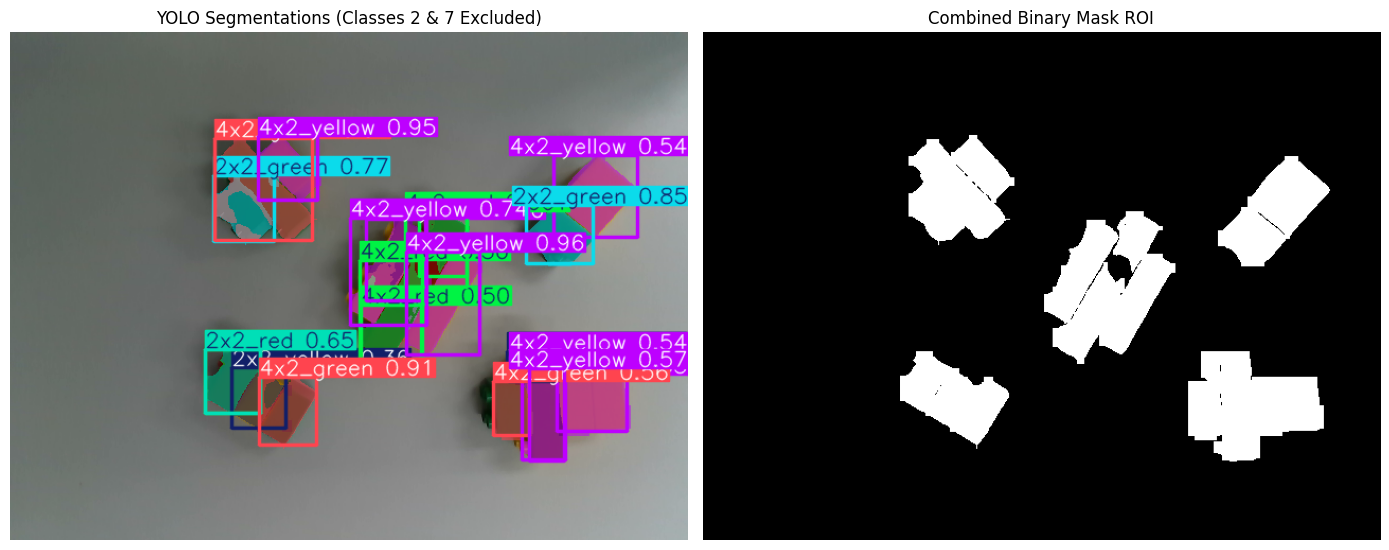

In [ ]:
# color_img_bgr, depth_img, intrinsics

# YOLOv8 추론 (2번, 7번 제외)
model = YOLO("yolo_models/manip_segmentor_0528.pt")
# model = YOLO("yolo_models/train1_05_04/weights/best.pt")

# ID 0~9 중 2와 7을 제외한 리스트 생성
target_classes = [0, 1, 3, 4, 5, 6, 8, 9] 

# 추론 시 classes 파라미터로 타겟 지정
results = model(color_img_bgr, classes=target_classes)

# 3. 마스크 병합 및 시각화용 이미지 생성
mask_binary = np.zeros((480, 640), dtype=np.uint8)

if len(results) > 0 and results[0].masks is not None:
    masks = results[0].masks.data.cpu().numpy()
    
    # 검출된 여러 개의 마스크를 하나의 ROI(관심 영역)로 합치기
    for mask in masks:
        mask_resized = cv2.resize(mask, (640, 480), interpolation=cv2.INTER_NEAREST)
        # 기존 마스크와 새로운 마스크를 OR 연산으로 겹쳐서 누적
        mask_binary = np.logical_or(mask_binary, mask_resized > 0.5).astype(np.uint8)
        
    print(f"[SUCCESS] {len(masks)}개의 타겟 객체 마스크 병합 완료")
else:
    print("[WARN] 지정된 클래스의 객체가 검출되지 않았습니다.")

# YOLO 내장 시각화 툴 활용 (바운딩 박스 + 라벨 + 세그멘테이션 색상)
vis_yolo = results[0].plot()

# --- 2D 검증 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(vis_yolo, cv2.COLOR_BGR2RGB))
axes[0].set_title("YOLO Segmentations (Classes 2 & 7 Excluded)")
axes[0].axis("off")

axes[1].imshow(mask_binary, cmap='gray')
axes[1].set_title("Combined Binary Mask ROI")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

[INFO] 억제됨: '4x2_green' (면적:5461)가 '4x2_green' (면적:7496)에 89.5% 포함됨.
[INFO] 억제됨: '4x2_green' (면적:4511)가 '4x2_green' (면적:7496)에 73.4% 포함됨.
[INFO] 억제됨: '4x2_green' (면적:2213)가 '2x2_green' (면적:2410)에 95.5% 포함됨.
[INFO] 억제됨: '2x2_blue' (면적:1687)가 '4x2_blue' (면적:2056)에 86.1% 포함됨.
[INFO] 억제됨: '2x2_blue' (면적:770)가 '4x2_blue' (면적:2056)에 71.8% 포함됨.
[INFO] 억제됨: '2x2_green' (면적:1867)가 '4x2_green' (면적:1868)에 98.6% 포함됨.
[INFO] 억제됨: '4x2_yellow' (면적:1828)가 '2x2_yellow' (면적:1854)에 99.9% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 16개
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 4x2_yellow
 - Name: 4x2_green
 - Name: 2x2_yellow
 - Name: 2x2_green
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 2x2_yellow
 - Name: 2x2_green
 - Name: 4x2_yellow
 - Name: 4x2_green
 - Name: 2x2_yellow
 - Name: 4x2_green
 - Name: 2x2_red
 - Name: 2x2_blue


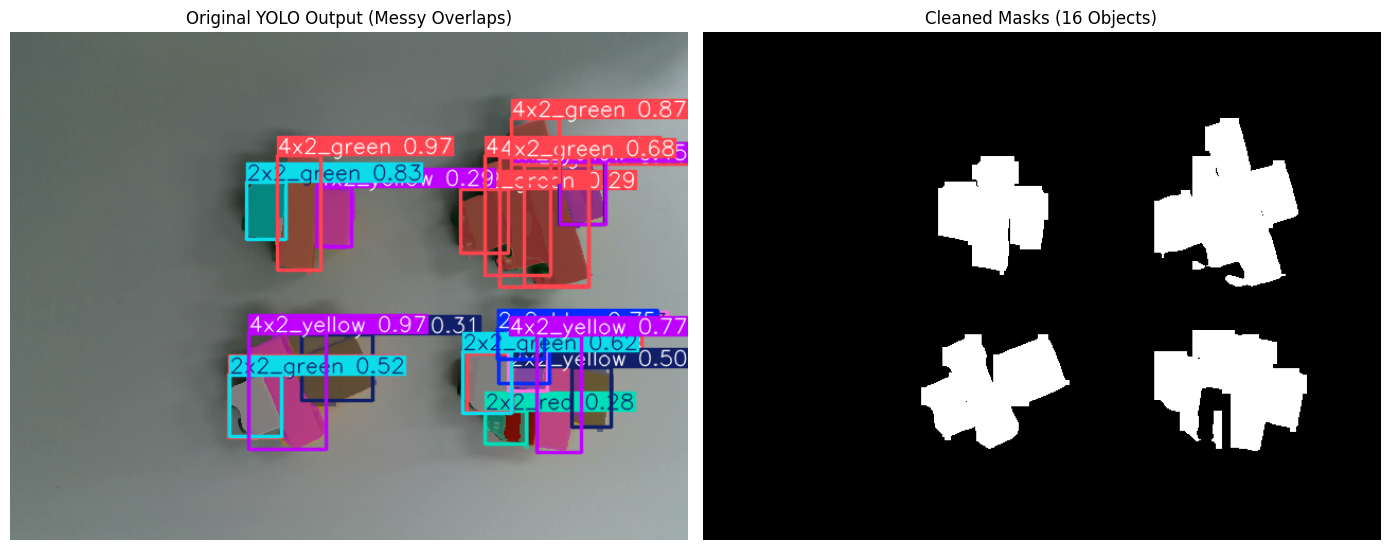

In [ ]:
import numpy as np
import cv2

# ==========================================
# 🎯 겹치는 마스크 병합 및 ID 정리 로직
# ==========================================

# 최종적으로 살아남은 객체들을 담을 리스트 (딕셔너리 형태)
final_detected_objects = []

if len(results) > 0 and results[0].masks is not None:
    # 1. 필요한 데이터 추출
    boxes = results[0].boxes
    masks = results[0].masks.data.cpu().numpy()  # 형상: (N, H, W)
    class_ids = boxes.cls.cpu().numpy().astype(int)
    confidences = boxes.conf.cpu().numpy()
    
    # YOLO 모델에 저장된 클래스 이름 딕셔너리 (예: {0: '1x2_red', 1: '2x4_red'...})
    class_names = model.names 

    # 2. 각 마스크의 픽셀 면적 계산
    areas = np.array([np.sum(mask > 0.5) for mask in masks])
    
    # 면적이 큰 순서대로 인덱스 정렬 (큰 객체가 작은 객체를 집어삼키도록 하기 위함)
    sorted_indices = np.argsort(-areas)
    
    suppressed_indices = set()  # 먹혀서 사라질(무시할) 작은 객체의 인덱스 모음
    overlap_threshold = 0.70    # 포함 판단 기준: 작은 마스크의 70% 이상이 겹치면 병합

    for i in range(len(sorted_indices)):
        idx_large = sorted_indices[i]
        
        # 이미 다른 큰 객체에 먹힌 객체라면 패스
        if idx_large in suppressed_indices:
            continue
            
        mask_large = masks[idx_large]
        area_large = areas[idx_large]
        
        # 현재 (가장 큰) 객체를 최종 리스트에 추가
        current_obj = {
            "class_id": class_ids[idx_large],
            "class_name": class_names[class_ids[idx_large]],
            "confidence": confidences[idx_large],
            "mask": cv2.resize(mask_large, (640, 480), interpolation=cv2.INTER_NEAREST) > 0.5
        }
        final_detected_objects.append(current_obj)
        
        # 3. 나보다 작은 나머지 객체들과 비교
        for j in range(i + 1, len(sorted_indices)):
            idx_small = sorted_indices[j]
            
            if idx_small in suppressed_indices:
                continue
                
            mask_small = masks[idx_small]
            area_small = areas[idx_small]
            
            # 두 마스크의 교집합(AND) 계산 (둘 다 1인 픽셀 수)
            intersection = np.sum(np.logical_and(mask_large > 0.5, mask_small > 0.5))
            
            # 작은 마스크가 큰 마스크에 얼마나 포함되어 있는지 비율 계산
            overlap_ratio = intersection / area_small if area_small > 0 else 0
            
            # 만약 작은 마스크의 대부분(70% 이상)이 겹친다면 오검출로 판단하고 억제
            if overlap_ratio > overlap_threshold:
                print(f"[INFO] 억제됨: '{class_names[class_ids[idx_small]]}' (면적:{area_small})가 "
                      f"'{class_names[class_ids[idx_large]]}' (면적:{area_large})에 {overlap_ratio*100:.1f}% 포함됨.")
                suppressed_indices.add(idx_small)
                
                # 💡 옵션: 작은 마스크의 삐져나온 영역까지 큰 객체의 마스크로 완전히 합치고 싶다면 아래 주석 해제
                # current_obj["mask"] = np.logical_or(current_obj["mask"], cv2.resize(mask_small, (640, 480), interpolation=cv2.INTER_NEAREST) > 0.5)

else:
    print("[WARN] 검출된 객체가 없습니다.")


# ==========================================
# 📊 검증: 최종 정리된 마스크 시각화 (기존 코드 유지)
# ==========================================
print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_detected_objects)}개")

final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_detected_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# (선택) plt로 결과 확인 (기존 시각화 코드 대체)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original YOLO Output (Messy Overlaps)")
axes[0].axis("off")

axes[1].imshow(final_combined_mask, cmap='gray')
axes[1].set_title(f"Cleaned Masks ({len(final_detected_objects)} Objects)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 높이 기준 거름 + 가로 세로 비율 기준 거름


[STEP 1] YOLOv8 마스크를 제외한 바닥(Background) 영역 추출 중...

[STEP 2] Open3D RANSAC 바닥 검출 및 평면 다림질 시작...
✅ 바닥 평면 방정식 도출: -0.011x + -0.000y + 1.000z + 0.402 = 0

[STEP 3] 바닥 기준 40mm(0.04m) 이상 돌출된 포인트 추출 중...
✅ 40mm 이상 돌출된 3D 포인트 개수: 0개

[STEP 4] YOLOv8 검출 영역과 40mm 이상 높이 맵 교집합 검사 및 ID 업데이트...

[STEP 5] 마스크 기반 OBB 추출 및 다중 조건 ID 교정 중...
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.02). '4x2_green' -> '[C]2x2_green'
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.38). '4x2_green' -> '[C]2x2_green'


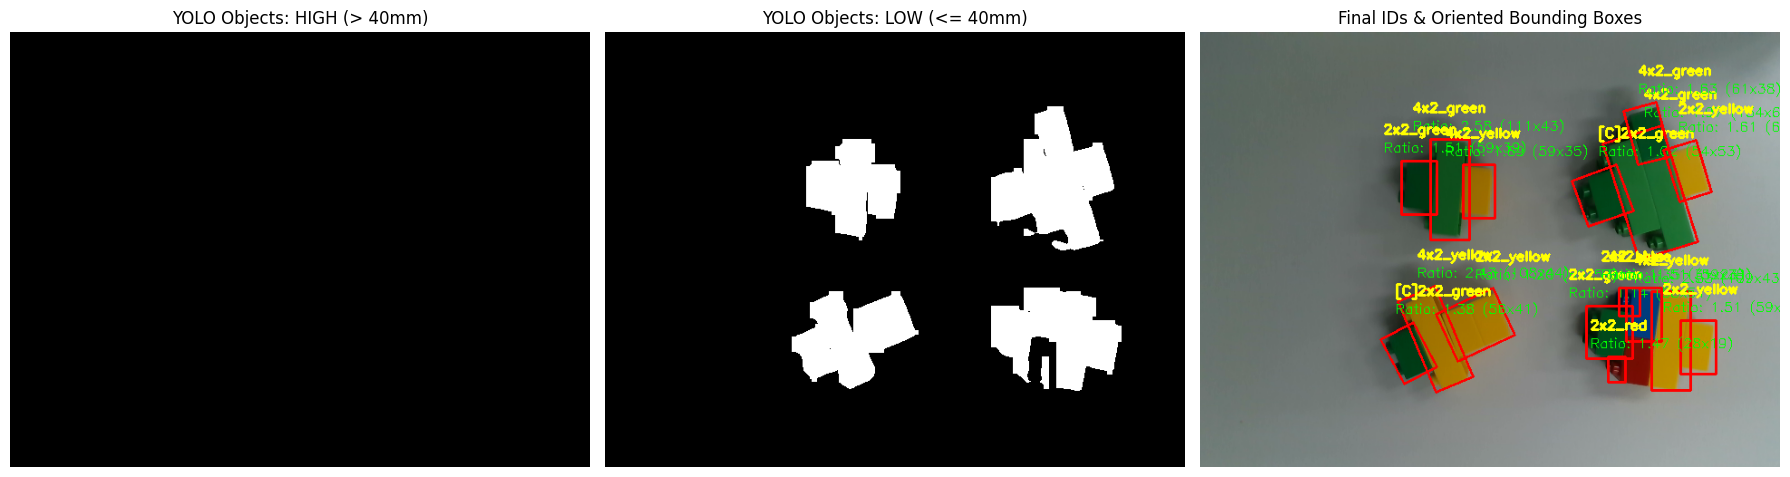

In [ ]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# =================================================================
# 1. 2D Depth Map 전처리 및 배경(바닥) 전용 Depth 추출
# =================================================================
print("\n[STEP 1] YOLOv8 마스크를 제외한 바닥(Background) 영역 추출 중...")

# 노이즈를 줄이기 위해 Median 블러 적용
filtered_depth_img = cv2.medianBlur(depth_img, 5)

# YOLOv8에서 중복 억제 후 최종 병합된 마스크(final_combined_mask) 사용
# 객체 주변의 여유 공간까지 확실히 날리기 위해 팽창(Dilate) 적용
kernel = np.ones((7, 7), np.uint8)
expanded_yolo_mask = cv2.dilate(final_combined_mask, kernel, iterations=3)

# 객체가 있는 영역의 Depth를 0으로 지워서 '순수한 바닥' 데이터만 남김
bg_depth_img = filtered_depth_img.copy()
bg_depth_img[expanded_yolo_mask > 0] = 0

# =================================================================
# 2. Open3D RANSAC 바닥 검출 및 다림질 (Flattening)
# =================================================================
print("\n[STEP 2] Open3D RANSAC 바닥 검출 및 평면 다림질 시작...")

# Open3D 카메라 파라미터 세팅
o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intrinsics.width), int(intrinsics.height),
    float(intrinsics.fx), float(intrinsics.fy),
    float(intrinsics.ppx), float(intrinsics.ppy)
)
o3d_depth_scale = 1.0 / float(depth_scale)

# 바닥 전용 포인트 클라우드 생성
bg_depth_o3d = o3d.geometry.Image(bg_depth_img)
bg_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    bg_depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
)
bg_pcd = bg_pcd.voxel_down_sample(voxel_size=0.003)

# 아웃라이어 제거
bg_pcd, _ = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# RANSAC 평면 검출
plane_model, inliers = bg_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
a, b, c, d = plane_model
plane_normal = np.array([a, b, c])

# 카메라 시점 방향 보정
if c > 0: 
    plane_normal = -plane_normal
    d = -d

print(f"✅ 바닥 평면 방정식 도출: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# =================================================================
# 3. 전체 씬(Full Scene)에서 바닥 기준 40mm(0.04m) 이상인 포인트 추출
# =================================================================
print("\n[STEP 3] 바닥 기준 40mm(0.04m) 이상 돌출된 포인트 추출 중...")

# 객체를 포함한 원본 전체 Depth로 Point Cloud 다시 생성
depth_o3d = o3d.geometry.Image(filtered_depth_img)
full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
)
full_pcd = full_pcd.voxel_down_sample(voxel_size=0.001)

# 평면 방정식을 이용해 바닥으로부터의 수직 높이(signed distance) 계산
points = np.asarray(full_pcd.points)
signed_height = np.dot(points, plane_normal) + d

# 🎯 핵심: 높이 임계값 40mm (0.04m) 이상인 점들만 마스킹
height_threshold = 0.040
above_40mm_indices = np.where(signed_height > height_threshold)[0]
pcd_above_40mm = full_pcd.select_by_index(above_40mm_indices)

print(f"✅ 40mm 이상 돌출된 3D 포인트 개수: {len(pcd_above_40mm.points)}개")

# =================================================================
# 4. 3D 포인트를 다시 2D 마스크로 사영 (Projection)
# =================================================================
def get_projected_mask(pcd_above, intrinsics, img_shape):
    h, w = img_shape[:2]
    projected_mask = np.zeros((h, w), dtype=np.uint8)
    obj_points = np.asarray(pcd_above.points)
    
    if len(obj_points) == 0:
        return projected_mask
        
    x_3d, y_3d, z_3d = obj_points[:, 0], obj_points[:, 1], obj_points[:, 2]
    z_3d = np.where(z_3d == 0, 0.00001, z_3d)
    
    u_coords = np.round((x_3d * intrinsics.fx / z_3d) + intrinsics.ppx).astype(int)
    v_coords = np.round((y_3d * intrinsics.fy / z_3d) + intrinsics.ppy).astype(int)
    
    valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
    projected_mask[v_coords[valid], u_coords[valid]] = 1
    
    # 미세한 구멍 메우기
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    projected_mask = cv2.morphologyEx(projected_mask, cv2.MORPH_CLOSE, kernel)
    return projected_mask

# 40mm 이상 객체들의 2D 위치 맵 획득
mask_40mm_2d = get_projected_mask(pcd_above_40mm, intrinsics, color_img_bgr.shape)

# =================================================================
# 5. YOLOv8 객체들과 40mm 2D 마스크 교집합 비교 및 ID(클래스명) 변경
# =================================================================
print("\n[STEP 4] YOLOv8 검출 영역과 40mm 이상 높이 맵 교집합 검사 및 ID 업데이트...")

# =================================================================
# 5. OBB 추출, 3D 높이 & OBB 비율 기반 ID 교정
# =================================================================
print("\n[STEP 5] 마스크 기반 OBB 추출 및 다중 조건 ID 교정 중...")

vis_image = color_img_bgr.copy()
N = 1.5  # 가로세로 비율 임계값

# 분리된 결과를 시각화하기 위한 빈 캔버스(마스크) 준비
h, w = color_img_bgr.shape[:2]
mask_high_vis = np.zeros((h, w), dtype=np.uint8)  # 높이 > 40mm 객체들
mask_low_vis = np.zeros((h, w), dtype=np.uint8)   # 높이 <= 40mm 객체들

for obj in final_detected_objects:
    yolo_mask = obj["mask"].astype(np.uint8)
    contours, _ = cv2.findContours(yolo_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        continue
        
    largest_contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest_contour)
    
    # 1. OBB 기반 물리적 가로/세로 비율 계산
    rect_w, rect_h = rect[1]
    ratio = max(rect_w, rect_h) / min(rect_w, rect_h) if min(rect_w, rect_h) > 0 else 0
    
    # 2. 40mm 돌출 맵과의 교집합 연산 (높이 판별)
    overlap = np.logical_and(yolo_mask, mask_40mm_2d)
    overlap_ratio = np.count_nonzero(overlap) / np.count_nonzero(yolo_mask)
    
    old_name = obj["class_name"]
    
    # 3. 높이 및 비율에 따른 분기 처리
    if overlap_ratio > 0.20:
        # [A] 높이가 높은 객체 (Stacked / 돌출됨)
        mask_high_vis = np.logical_or(mask_high_vis, yolo_mask).astype(np.uint8)
        
        # ID가 2x2라면 4x2로 교정하고 [C] 태그 부착
        if "2x2" in old_name:
            new_name = old_name.replace("2x2", "4x2")
            obj["class_name"] = f"[C]{new_name}"
            print(f" ⚠️ [높이 교정] 쌓인 블록 감지! '{old_name}' -> '{obj['class_name']}'")
            
    else:
        # [B] 높이가 낮은 객체 (바닥에 있는 단일 블록)
        mask_low_vis = np.logical_or(mask_low_vis, yolo_mask).astype(np.uint8)
        
        # ID가 4x2 (또는 2x4)인데, OBB 비율이 N(2.0) 이하라면 2x2로 교정하고 [C] 태그 부착
        if "4x2" in old_name or "2x4" in old_name:
            if ratio <= N:
                new_name = old_name.replace("4x2", "2x2").replace("2x4", "2x2")
                obj["class_name"] = f"[C]{new_name}"
                print(f" 🔍 [비율 교정] 짧은 블록 감지 (비율:{ratio:.2f}). '{old_name}' -> '{obj['class_name']}'")

    # 4. 시각화 렌더링 (OBB 박스 및 텍스트)
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    cv2.drawContours(vis_image, [box], 0, (0, 0, 255), 2)
    
    top_point = box[np.argmin(box[:, 1])]
    
    label_name = f"{obj['class_name']}"
    label_ratio = f"Ratio: {ratio:.2f} ({max(rect_w, rect_h):.0f}x{min(rect_w, rect_h):.0f})"
    
    # ID 표기 (노란색)
    cv2.putText(vis_image, label_name, (top_point[0] - 20, top_point[1] - 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
    # 비율 표기 (초록색)
    cv2.putText(vis_image, label_ratio, (top_point[0] - 20, top_point[1] - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# =================================================================
# 6. 최종 분할 마스크 및 결과 시각화
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 40mm 이상 돌출된 영역과 겹치는 YOLO 객체 마스크
axes[0].imshow(mask_high_vis, cmap="gray")
axes[0].set_title("YOLO Objects: HIGH (> 40mm)")
axes[0].axis("off")

# 2. 바닥 평면(40mm 이하)에 위치한 YOLO 객체 마스크
axes[1].imshow(mask_low_vis, cmap="gray")
axes[1].set_title("YOLO Objects: LOW (<= 40mm)")
axes[1].axis("off")

# 3. 최종 교정된 ID와 OBB가 적용된 컬러 맵
vis_image_rgb = cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)
axes[2].imshow(vis_image_rgb)
axes[2].set_title("Final IDs & Oriented Bounding Boxes")
axes[2].axis("off")

plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #39FF14; border: none;">

### Ransac 바닥 검출


[STEP 1] Depth Map 전처리 시작...

[STEP 2] Point Cloud 생성 및 다운샘플링 (Voxel: 3mm)...
[STEP 3] 노이즈 아웃라이어 제거 중...

[STEP 4] DBSCAN으로 바닥 영역만 타겟팅 후 RANSAC 평면 도출...
 -> 바닥 평면 방정식 도출: -0.016x + 0.011y + 1.000z + 0.400 = 0

[STEP 5] 평면 기준 5mm(0.005m) 이상 튀어나온 객체 추출...
 -> 3327개의 돌출된 3D 객체 포인트 확보 완료.

[STEP 6] 3D 돌출 객체를 2D 컬러 맵에 맞게 사영 및 마스킹 중...

[STEP 7] AND 연산을 생략하고 기존 3D 돌출 마스크를 모폴로지 연산으로 정제합니다...
 -> 추출된 외곽선(객체 덩어리) 개수: 14개


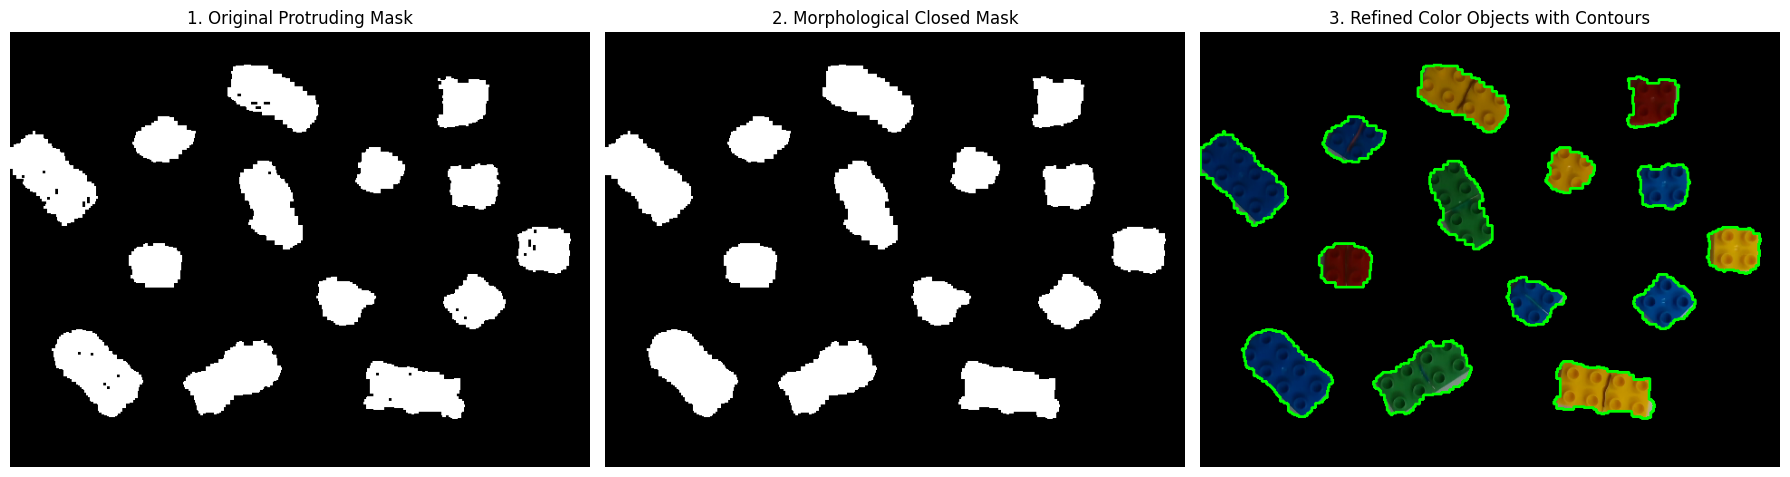

In [ ]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# =================================================================
# 1. 2D Depth Map 전처리: Median Filter
# =================================================================
print("\n[STEP 1] Depth Map 전처리 시작...")
filtered_depth_img = cv2.medianBlur(depth_img, 5)

# =================================================================
# 2. Open3D Intrinsic 및 Scale 설정
# =================================================================
o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intrinsics.width), int(intrinsics.height),
    float(intrinsics.fx), float(intrinsics.fy),
    float(intrinsics.ppx), float(intrinsics.ppy)
)
o3d_depth_scale = 1.0 / float(depth_scale)

# =================================================================
# 3. 포인트 클라우드 생성 및 다운샘플링 (Single Track)
# =================================================================
print("\n[STEP 2] Point Cloud 생성 및 다운샘플링 (Voxel: 3mm)...")
depth_o3d = o3d.geometry.Image(filtered_depth_img)
full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
)

# 전체 씬 포인트 클라우드 (다운샘플링 적용)
pcd = full_pcd.voxel_down_sample(voxel_size=0.003) 

# =================================================================
# 4. 아웃라이어 제거 (Statistical & Radius)
# =================================================================
print("[STEP 3] 노이즈 아웃라이어 제거 중...")
pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
pcd, _ = pcd.remove_radius_outlier(nb_points=10, radius=0.01)

# =================================================================
# 5. [수정됨] 바닥면 검출을 위한 타겟 분리 (DBSCAN + RANSAC)
# =================================================================
print("\n[STEP 4] DBSCAN으로 바닥 영역만 타겟팅 후 RANSAC 평면 도출...")
labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=20, print_progress=False))

# 바닥 방정식 초기화
a, b, c, d = 0, 0, 1, 0  

if len(labels) > 0 and labels.max() >= 0:
    # 💡 핵심: 원본 pcd는 그대로 두고, 바닥을 찾을 용도의 pcd만 임시로 분리합니다.
    largest_cluster_idx = np.argmax(np.bincount(labels[labels >= 0]))
    main_cluster_indices = np.where(labels == largest_cluster_idx)[0]
    
    floor_candidate_pcd = pcd.select_by_index(main_cluster_indices)
    
    # 임시 분리된 바닥 후보에서 RANSAC 실행
    plane_model, inliers = floor_candidate_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
    a, b, c, d = plane_model
    plane_normal = np.array([a, b, c])

    # 카메라 시점 방향 보정 (Z축이 양수가 되도록)
    if c > 0: 
        plane_normal = -plane_normal
        d = -d

print(f" -> 바닥 평면 방정식 도출: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# =================================================================
# 6. 바닥 기준 돌출된(양수 뎁스) 객체 포인트 추출
# =================================================================
print("\n[STEP 5] 평면 기준 5mm(0.005m) 이상 튀어나온 객체 추출...")
points = np.asarray(pcd.points)

# 평면 방정식 기반 Signed Height 계산 (전체 pcd 대상)
signed_height = np.dot(points, plane_normal) + d

# 💡 바닥(0)보다 5mm 이상 위로 솟아오른 점들만 추출
object_indices = np.where(signed_height > 0.005)[0]
object_pcd = pcd.select_by_index(object_indices)
object_points = np.asarray(object_pcd.points)

print(f" -> {len(object_points)}개의 돌출된 3D 객체 포인트 확보 완료.")

# =================================================================
# 7. 객체 포인트를 2D 활성화 마스크로 사영 (Projection)
# =================================================================
print("\n[STEP 6] 3D 돌출 객체를 2D 컬러 맵에 맞게 사영 및 마스킹 중...")
h, w = color_img_bgr.shape[:2]
object_mask_2d = np.zeros((h, w), dtype=np.uint8)

if len(object_points) > 0:
    fx, fy = intrinsics.fx, intrinsics.fy
    cx, cy = intrinsics.ppx, intrinsics.ppy

    x_3d, y_3d = object_points[:, 0], object_points[:, 1]
    z_3d = np.where(object_points[:, 2] == 0, 0.00001, object_points[:, 2])

    u_coords = np.round((x_3d * fx / z_3d) + cx).astype(int)
    v_coords = np.round((y_3d * fy / z_3d) + cy).astype(int)

    valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
    object_mask_2d[v_coords[valid], u_coords[valid]] = 1

# 3mm 다운샘플링으로 인한 구멍(Hole)을 강하게 메워줍니다.
kernel_fill = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
object_mask_filled = cv2.dilate(object_mask_2d, kernel_fill, iterations=1)
object_mask_filled = cv2.morphologyEx(object_mask_filled, cv2.MORPH_CLOSE, kernel_fill)

# =================================================================
# 8. 컬러 이미지 컷오프 (마스킹 적용)
# =================================================================
# 마스크가 1인 곳(객체)만 원본 컬러 이미지 픽셀을 남기고 나머지는 검은색 처리
cut_color_img = cv2.bitwise_and(color_img_bgr, color_img_bgr, mask=object_mask_filled)
# =================================================================
# 10. 마스크 후처리 (모폴로지 연산으로 구멍/잔상 제거 및 윤곽선 추출)
# =================================================================
print("\n[STEP 7] AND 연산을 생략하고 기존 3D 돌출 마스크를 모폴로지 연산으로 정제합니다...")

# OpenCV 처리를 위해 0과 1로 된 마스크를 0과 255 스케일로 변환
mask_255 = (object_mask_filled * 255).astype(np.uint8)

# 1. 7x7 커널로 닫힘(Close) 연산: 마스크 내부의 까만 점(구멍)이나 끊어진 부분을 메워줍니다.
kernel = np.ones((7, 7), np.uint8)
closed_mask = cv2.morphologyEx(mask_255, cv2.MORPH_CLOSE, kernel)

# 💡 (선택) 만약 마스크 '바깥쪽'에 하얀색 잔상 노이즈(작은 점)가 떠다닌다면 
# 아래 주석을 해제하여 열림(Open) 연산을 추가로 적용하세요. (테두리를 깔끔하게 깎아냅니다)
# closed_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel)

# 2. 마스크 내의 모든 윤곽선(Contours) 찾기
contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f" -> 추출된 외곽선(객체 덩어리) 개수: {len(contours)}개")

# 3. 정제된 마스크를 기반으로 원본 컬러 이미지 컷오프
# closed_mask는 이미 0과 255로 이루어져 있으므로 mask 파라미터로 바로 사용 가능합니다.
refined_color_img = cv2.bitwise_and(color_img_bgr, color_img_bgr, mask=closed_mask)

# =================================================================
# 11. 최종 정제된 결과 시각화
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 기존 RANSAC 마스크 (정제 전)
axes[0].imshow(object_mask_filled, cmap="gray")
axes[0].set_title("1. Original Protruding Mask")
axes[0].axis("off")

# 2. 모폴로지 연산이 적용된 마스크 (정제 후)
axes[1].imshow(closed_mask, cmap="gray")
axes[1].set_title("2. Morphological Closed Mask")
axes[1].axis("off")

# 3. 최종 컬러 컷오프 이미지
# 외곽선을 눈으로 확인하기 위해 이미지 위에 초록색으로 Contours를 그립니다.
vis_refined_color = refined_color_img.copy()
cv2.drawContours(vis_refined_color, contours, -1, (0, 255, 0), 2)

axes[2].imshow(cv2.cvtColor(vis_refined_color, cv2.COLOR_BGR2RGB))
axes[2].set_title("3. Refined Color Objects with Contours")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## convex hull 적용

[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...
[SUCCESS] 2D 객체 마스크 복원 완료!


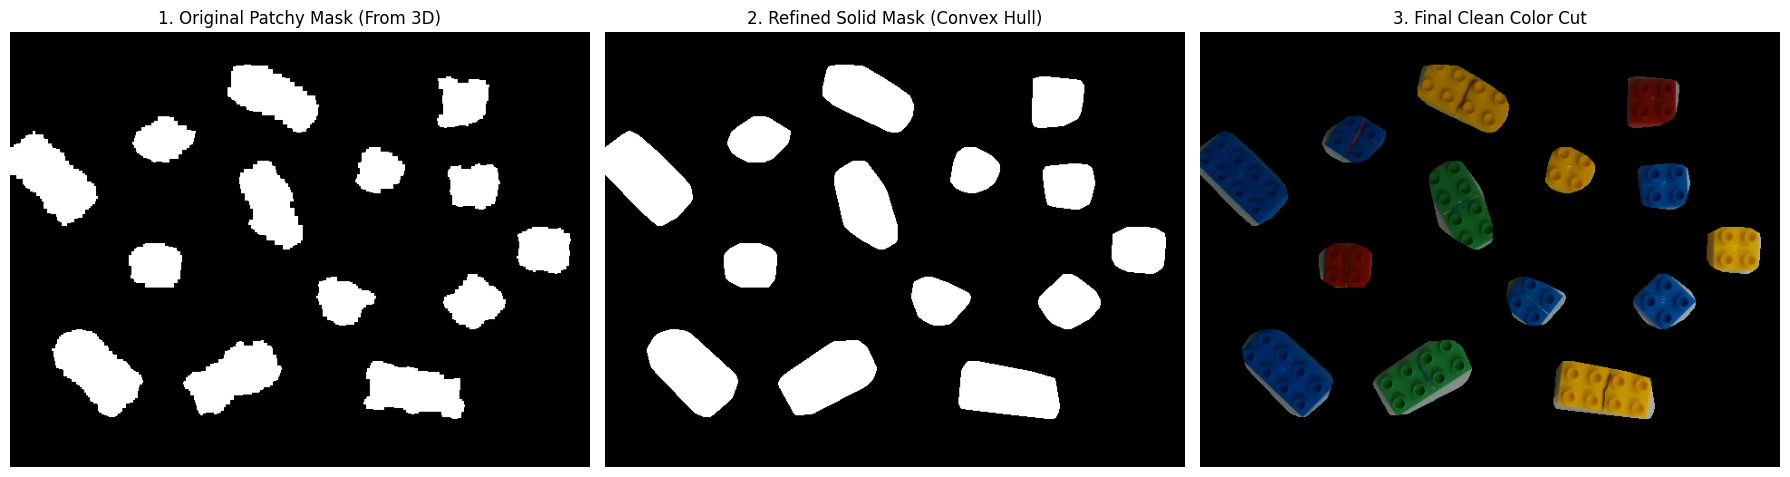

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt




# =================================================================
# 🎯 [실행 파트] 조각난 마스크 복원
# =================================================================
print("[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...")

refined_mask_01, final_cut_color = ivl.refine_2d_mask_with_hull(
    projected_mask_01=closed_mask, 
    color_bgr=color_img_bgr
)

print("[SUCCESS] 2D 객체 마스크 복원 완료!")

# ---------------------------------------------------------
# 결과 시각화 비교
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(closed_mask, cmap="gray")
axes[0].set_title("1. Original Patchy Mask (From 3D)")
axes[0].axis("off")

axes[1].imshow(refined_mask_01, cmap="gray")
axes[1].set_title("2. Refined Solid Mask (Convex Hull)")
axes[1].axis("off")

final_cut_rgb = cv2.cvtColor(final_cut_color, cv2.COLOR_BGR2RGB)
axes[2].imshow(final_cut_rgb)
axes[2].set_title("3. Final Clean Color Cut")
axes[2].axis("off")

plt.tight_layout()
plt.show()



[STEP 1] Depth 전처리 및 단일 포인트 클라우드 생성...

[STEP 2] RANSAC 바닥 검출 및 평탄화(다림질)...

[STEP 3] 돌출 객체 2D 마스크 생성 및 Convex Hull 복원...

[STEP 4] YOLO 마스크와 3D 데이터 매칭 및 높이 분석 중...

[STEP 5] 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링 중...
 🎯 [높이 강제 고정] 가장 낮은 객체('[C]2x2_blue')의 3D 박스 높이를 16.3mm -> 24.0mm 로 수정했습니다.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20004\772081714.py:217: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")


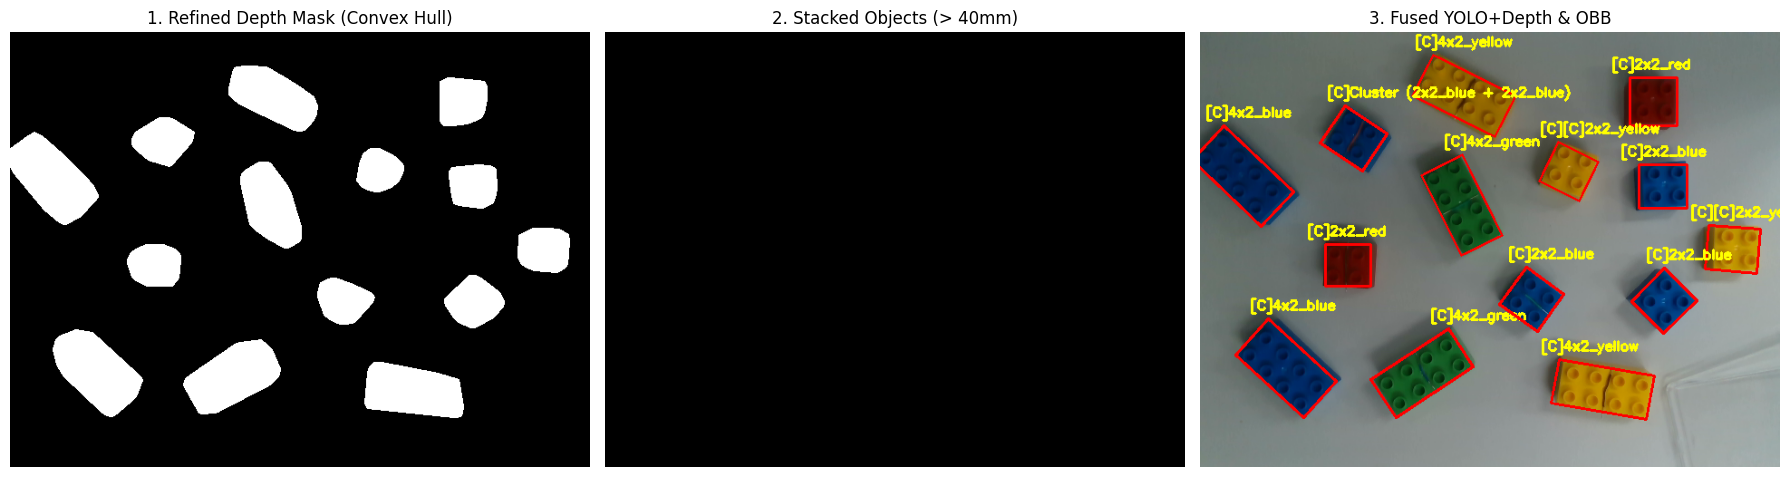


[INFO] 1번 시각화 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.

[STEP 6] 원본 컬러 포인트 클라우드 생성 및 OBB 오버레이 중...
[INFO] 2번 시각화 창(원본 RGB-D 오버레이)을 엽니다.


In [ ]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.cm as cm



# =================================================================
# 1. Depth 전처리 및 3D 점군 생성 (Single Track)
# =================================================================
print("\n[STEP 1] Depth 전처리 및 단일 포인트 클라우드 생성...")
filtered_depth_img = cv2.medianBlur(depth_img, 5)

o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intrinsics.width), int(intrinsics.height),
    float(intrinsics.fx), float(intrinsics.fy),
    float(intrinsics.ppx), float(intrinsics.ppy)
)
o3d_depth_scale = 1.0 / float(depth_scale)

depth_o3d = o3d.geometry.Image(filtered_depth_img)
pcd = o3d.geometry.PointCloud.create_from_depth_image(
    depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
)
pcd = pcd.voxel_down_sample(voxel_size=0.003)
pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
pcd, _ = pcd.remove_radius_outlier(nb_points=10, radius=0.01)

# =================================================================
# 2. RANSAC 바닥 검출 및 다림질
# =================================================================
print("\n[STEP 2] RANSAC 바닥 검출 및 평탄화(다림질)...")
labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=20, print_progress=False))
if len(labels) > 0 and labels.max() >= 0:
    main_cluster_indices = np.where(labels == np.argmax(np.bincount(labels[labels >= 0])))[0]
    floor_candidate_pcd = pcd.select_by_index(main_cluster_indices)
    plane_model, _ = floor_candidate_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
    a, b, c, d = plane_model
    plane_normal = np.array([a, b, c])
    if c > 0:
        plane_normal = -plane_normal
        d = -d

points = np.asarray(pcd.points)
signed_height = np.dot(points, plane_normal) + d

# 바닥 포인트 평탄화
floor_indices = np.where(signed_height <= 0.005)[0]
floor_pcd = pcd.select_by_index(floor_indices)
floor_points = np.asarray(floor_pcd.points)
distances = np.dot(floor_points, plane_normal) + d
flattened_points = floor_points - np.outer(distances, plane_normal)
floor_pcd.points = o3d.utility.Vector3dVector(flattened_points)
floor_pcd.paint_uniform_color([0.8, 0.8, 0.8])

# =================================================================
# 3. 돌출 영역 2D 사영 및 Convex Hull 마스크 복원
# =================================================================
print("\n[STEP 3] 돌출 객체 2D 마스크 생성 및 Convex Hull 복원...")
h, w = color_img_bgr.shape[:2]

def get_projected_mask(height_threshold):
    indices = np.where(signed_height > height_threshold)[0]
    obj_pts = points[indices]
    mask_2d = np.zeros((h, w), dtype=np.uint8)
    if len(obj_pts) > 0:
        x_3d, y_3d = obj_pts[:, 0], obj_pts[:, 1]
        z_3d = np.where(obj_pts[:, 2] == 0, 0.00001, obj_pts[:, 2])
        u_coords = np.round((x_3d * intrinsics.fx / z_3d) + intrinsics.ppx).astype(int)
        v_coords = np.round((y_3d * intrinsics.fy / z_3d) + intrinsics.ppy).astype(int)
        valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
        mask_2d[v_coords[valid], u_coords[valid]] = 1
    return mask_2d

# 5mm(마스크 복원용)와 40mm(높이 판별용) 마스크 생성
mask_5mm_2d = get_projected_mask(0.005)
mask_40mm_2d = get_projected_mask(0.040)

# Convex Hull을 이용해 5mm 마스크 정밀 복원
refined_mask_01, final_cut_color = refine_2d_mask_with_hull(mask_5mm_2d, color_img_bgr)

# =================================================================
# 4. YOLO + Depth 융합, ID 교정 및 객체 데이터 수집
# =================================================================
print("\n[STEP 4] YOLO 마스크와 3D 데이터 매칭 및 높이 분석 중...")

vis_image = color_img_bgr.copy()
N = 1.5
mask_high_vis = np.zeros((h, w), dtype=np.uint8)
mask_low_vis = np.zeros((h, w), dtype=np.uint8)

# 3D -> 2D 픽셀 맵핑 사전 준비
z_3d_safe = np.where(points[:, 2] == 0, 0.00001, points[:, 2])
u_all = np.round((points[:, 0] * intrinsics.fx / z_3d_safe) + intrinsics.ppx).astype(int)
v_all = np.round((points[:, 1] * intrinsics.fy / z_3d_safe) + intrinsics.ppy).astype(int)
valid_idx = (u_all >= 0) & (u_all < w) & (v_all >= 0) & (v_all < h)
u_valid, v_valid = u_all[valid_idx], v_all[valid_idx]
points_valid = points[valid_idx]
heights_valid = signed_height[valid_idx]

vis_elements = [floor_pcd] if 'floor_pcd' in locals() else []
color_dict = {}
cmap = cm.get_cmap("tab20")

# 🌟 객체 렌더링 정보를 임시로 담아둘 리스트 생성
object_data_list = []

for obj in final_detected_objects:
    yolo_mask = obj["mask"].astype(np.uint8)
    
    # YOLO 마스크와 복원된 뎁스 마스크 교집합 적용
    fused_mask = np.logical_and(yolo_mask > 0, refined_mask_01 > 0).astype(np.uint8)
    
    contours, _ = cv2.findContours(fused_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        continue
        
    largest_contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest_contour)
    
    rect_w, rect_h = rect[1]
    ratio = max(rect_w, rect_h) / min(rect_w, rect_h) if min(rect_w, rect_h) > 0 else 0
    
    overlap_40mm = np.logical_and(fused_mask, mask_40mm_2d)
    overlap_ratio = np.count_nonzero(overlap_40mm) / np.count_nonzero(fused_mask)
    
    if "original_name" not in obj:
        obj["original_name"] = obj["class_name"]
    old_name = obj["original_name"]
    
    # [ID 교정 로직]
    if overlap_ratio > 0.20:
        mask_high_vis = np.logical_or(mask_high_vis, fused_mask).astype(np.uint8)
        if "2x2" in old_name:
            obj["class_name"] = f"[C]{old_name.replace('2x2', '4x2')}"
        else:
            obj["class_name"] = f"[C]{old_name}"
    else:
        mask_low_vis = np.logical_or(mask_low_vis, fused_mask).astype(np.uint8)
        if ("4x2" in old_name or "2x4" in old_name) and ratio <= N:
            obj["class_name"] = f"[C]{old_name.replace('4x2', '2x2').replace('2x4', '2x2')}"
        else:
            obj["class_name"] = f"[C]{old_name}"

    final_id = obj["class_name"]

    # 3D 객체 포인트 추출 및 최대 높이 계산
    in_mask_pixels = fused_mask[v_valid, u_valid] > 0
    obj_heights = heights_valid[in_mask_pixels]
    
    if len(obj_heights) > 0:
        max_h = np.percentile(obj_heights, 95)
        max_h = max(max_h, 0.005) # 최소 5mm 보장
    else:
        continue # 3D 포인트가 전혀 없는 오검출 객체는 스킵

    # 수집된 데이터를 리스트에 저장 (아직 그리지 않음)
    object_data_list.append({
        "final_id": final_id,
        "rect": rect,
        "in_mask_pixels": in_mask_pixels,
        "max_h": max_h
    })

# =================================================================
# 5. 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링
# =================================================================
print("\n[STEP 5] 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링 중...")

# 🌟 원본 컬러 포인트 클라우드에 덮어씌울 박스와 좌표계를 따로 보관할 리스트
overlay_geometries = []

if object_data_list:
    # 🎯 핵심: 수집된 객체들 중 max_h가 가장 작은(가장 낮은) 객체의 인덱스 찾기
    min_idx = min(range(len(object_data_list)), key=lambda i: object_data_list[i]["max_h"])
    old_h = object_data_list[min_idx]["max_h"]
    
    # 가장 낮은 객체의 높이를 24mm (0.024m)로 강제 고정
    object_data_list[min_idx]["max_h"] = 0.024
    print(f" 🎯 [높이 강제 고정] 가장 낮은 객체('{object_data_list[min_idx]['final_id']}')의 3D 박스 높이를 {old_h*1000:.1f}mm -> 24.0mm 로 수정했습니다.")

for data in object_data_list:
    final_id = data["final_id"]
    rect = data["rect"]
    in_mask_pixels = data["in_mask_pixels"]
    max_h = data["max_h"]

    if final_id not in color_dict:
        color_dict[final_id] = cmap(len(color_dict) % 20)[:3]
    obj_color = color_dict[final_id]

# 3D 포인트 채색 및 추가
    obj_pcd = o3d.geometry.PointCloud()
    obj_pcd.points = o3d.utility.Vector3dVector(points_valid[in_mask_pixels])
    obj_pcd.paint_uniform_color(obj_color)
    vis_elements.append(obj_pcd)

    # 3D OBB 및 좌표계 생성
    box_2d = cv2.boxPoints(rect)
    box_2d = np.intp(box_2d)
    
    box_3d, axes_3d = create_floor_anchored_3d_box_with_axes(
        box_2d, intrinsics, plane_normal, d, max_h, obj_color, axis_size=0.03
    )
    
    # 1. 기존 분석용 시각화 리스트에 추가
    vis_elements.append(box_3d)
    vis_elements.append(axes_3d)
    
    # 2. 🌟 나중에 원본 RGB 맵에 덮어씌우기 위해 따로 보관
    overlay_geometries.append(box_3d)
    overlay_geometries.append(axes_3d)
    
    # 2D 시각화 텍스트/박스 그리기
    cv2.drawContours(vis_image, [box_2d], 0, (0, 0, 255), 2)
    top_point = box_2d[np.argmin(box_2d[:, 1])]
    cv2.putText(vis_image, final_id, (top_point[0] - 20, top_point[1] - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

# =================================================================
# 6. 시각화 출력 (이후 코드는 동일)
# =================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(refined_mask_01, cmap="gray")
axes[0].set_title("1. Refined Depth Mask (Convex Hull)")
axes[0].axis("off")

axes[1].imshow(mask_high_vis, cmap="gray")
axes[1].set_title("2. Stacked Objects (> 40mm)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
axes[2].set_title("3. Fused YOLO+Depth & OBB")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 🎯 첫 번째 뷰어: 기존 분석용 3D 객체 및 바운딩 박스
print("\n[INFO] 1번 시각화 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.")
o3d.visualization.draw_geometries(vis_elements, window_name="1. Analytical 3D Clustered Objects & OBBs")

# =================================================================
# [NEW STEP] 실제 컬러가 입혀진 원본 포인트 클라우드(RGB-D) 생성 및 오버레이
# =================================================================
print("\n[STEP 6] 원본 컬러 포인트 클라우드 생성 및 OBB 오버레이 중...")

# 1. BGR 이미지를 Open3D용 RGB 포맷으로 변환
color_img_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

# 2. Open3D Image 객체로 변환
color_o3d = o3d.geometry.Image(color_img_rgb)
# Median 필터링된 뎁스를 사용하여 노이즈를 줄인 원본 뎁스 맵 사용
depth_o3d_raw = o3d.geometry.Image(filtered_depth_img)

# 3. RGB-D 이미지 생성 (색상과 뎁스 결합)
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_o3d, depth_o3d_raw,
    depth_scale=o3d_depth_scale,
    depth_trunc=1.5,
    convert_rgb_to_intensity=False # 흑백 변환 방지 (컬러 유지)
)

# 4. 카메라 파라미터를 이용해 실제 색상이 입혀진 원본 3D 포인트 클라우드 생성
rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image, o3d_intr
)

# 시각화 최적화를 위해 살짝 다운샘플링 (1.5mm 간격)
# 원본 해상도를 그대로 띄우면 뷰어가 너무 무거워질 수 있습니다.
rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

# 5. 원본 포인트 클라우드 리스트에 앞서 따로 보관해둔 바운딩 박스와 좌표계 리스트를 합침
final_overlay_elements = [rgb_pcd] + overlay_geometries

# 🎯 두 번째 뷰어: 실제 사진 맵 + 바운딩 박스 오버레이
print("[INFO] 2번 시각화 창(원본 RGB-D 오버레이)을 엽니다.")
o3d.visualization.draw_geometries(final_overlay_elements, window_name="2. Real RGB-D Point Cloud with OBBs & Axes")